# Version A Full Experiment Notebook

This notebook completes Version A as a lightweight metadata-first recommendation track for NutriMatch.

It implements and evaluates:

- **A0 Bayesian popularity baseline**
- **A1 constrained popularity demo**
- **A2 TF-IDF item-to-item content recommendation**
- **A3 user-profile content recommendation**
- **A4 content plus popularity reranker**
- **A5 required latent semantic content model with TruncatedSVD**

The notebook is designed for a Colab GPU runtime with the project stored in Google Drive at `/content/drive/MyDrive/513`. It uses progress bars, runtime tracking, metric plots, tuning plots, recommendation examples, model artifact exports, and explanation visualizations.

## How to Use This Notebook

1. Put the full project folder in Google Drive at `MyDrive/513`.
2. Make sure `MyDrive/513/Final/Data/Pure_Data` contains the processed CSV files.
3. Open this notebook from a Colab GPU runtime.
4. Run the setup/import cell.
5. Run the Google Drive mount cell.
6. Run the GPU verification cell and confirm the GPU is visible.
7. Run the path/config cells and confirm `WORKSPACE_ROOT` is `/content/drive/MyDrive/513`.
8. Start with sampled evaluation mode.
9. After sampled mode works, enable full filtered evaluation for final metrics.

Recommended first run:

- `fast_dev_mode = True`
- `eval_user_sample_size = 1000`
- `run_full_filtered_eval = False`
- `run_svd_model = True`

Recommended final run:

- `fast_dev_mode = False`
- `run_full_filtered_eval = True`
- `run_svd_model = True`


In [1]:
from __future__ import annotations

import json
import math
import pickle
import time
import warnings
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Any, Iterable

import numpy as np
import pandas as pd
import scipy.sparse as sp

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 513
rng = np.random.default_rng(RANDOM_STATE)

## Mount Google Drive

Run this cell before the path cell. It mounts your Google Drive so the notebook can read `/content/drive/MyDrive/513`.

In [2]:
# Mount Google Drive for Colab runtime.
try:
    from google.colab import drive
except ImportError as exc:
    raise RuntimeError(
        "google.colab is not available. Use a Colab runtime, or change WORKSPACE_ROOT to a path visible to this kernel."
    ) from exc

drive.mount("/content/drive", force_remount=False)
print("Google Drive mounted at /content/drive")


Mounted at /content/drive
Google Drive mounted at /content/drive


## GPU Verification

Run this cell after mounting Google Drive. It confirms that the Colab runtime exposes an NVIDIA GPU through `nvidia-smi`, PyTorch, or TensorFlow. This notebook is configured to stop if no GPU is visible, so you can verify that the Colab web runtime is actually using a GPU.

In [3]:
# GPU verification for Colab web runtime.
# This is intentionally strict so you can confirm that GPU is really connected.
import os
import platform
import shutil
import subprocess

REQUIRE_GPU_RUNTIME = True

gpu_rows: list[dict[str, Any]] = []
framework_rows: list[dict[str, Any]] = []

nvidia_smi = shutil.which("nvidia-smi")
if nvidia_smi:
    try:
        result = subprocess.run(
            [
                nvidia_smi,
                "--query-gpu=index,name,memory.total,memory.free,driver_version",
                "--format=csv,noheader,nounits",
            ],
            check=True,
            capture_output=True,
            text=True,
        )
        for line in result.stdout.strip().splitlines():
            parts = [part.strip() for part in line.split(",")]
            if len(parts) >= 5:
                gpu_rows.append(
                    {
                        "gpu_index": parts[0],
                        "gpu_name": parts[1],
                        "memory_total_mb": float(parts[2]),
                        "memory_free_mb": float(parts[3]),
                        "driver_version": parts[4],
                    }
                )
    except Exception as exc:
        framework_rows.append({"framework": "nvidia-smi", "gpu_available": False, "detail": repr(exc)})
else:
    framework_rows.append({"framework": "nvidia-smi", "gpu_available": False, "detail": "nvidia-smi not found"})

try:
    import torch

    torch_gpu_available = bool(torch.cuda.is_available())
    framework_rows.append(
        {
            "framework": "PyTorch",
            "gpu_available": torch_gpu_available,
            "detail": torch.cuda.get_device_name(0) if torch_gpu_available else "torch.cuda.is_available() is False",
        }
    )
except Exception as exc:
    framework_rows.append({"framework": "PyTorch", "gpu_available": False, "detail": f"not available: {exc}"})

try:
    import tensorflow as tf

    tf_gpus = tf.config.list_physical_devices("GPU")
    framework_rows.append(
        {
            "framework": "TensorFlow",
            "gpu_available": bool(tf_gpus),
            "detail": ", ".join(device.name for device in tf_gpus) if tf_gpus else "no TensorFlow GPU devices",
        }
    )
except Exception as exc:
    framework_rows.append({"framework": "TensorFlow", "gpu_available": False, "detail": f"not available: {exc}"})

gpu_df = pd.DataFrame(gpu_rows)
framework_df = pd.DataFrame(framework_rows)

print("Python:", platform.python_version())
print("Runtime:", platform.platform())
print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES", "<not set>"))

if not gpu_df.empty:
    display(Markdown("### GPU Device Detected"))
    display(gpu_df)
else:
    display(Markdown("### No GPU Device Reported by nvidia-smi"))

if not framework_df.empty:
    display(Markdown("### Framework GPU Visibility"))
    display(framework_df)

has_gpu_runtime = bool(gpu_rows) or bool(framework_df["gpu_available"].any())

if has_gpu_runtime:
    display(Markdown("**GPU runtime verified.** This Colab runtime exposes a GPU."))
else:
    display(Markdown("**No GPU detected.** In Colab, choose `Runtime > Change runtime type > GPU`, then reconnect the runtime."))
    if REQUIRE_GPU_RUNTIME:
        raise RuntimeError("No GPU detected. Switch Colab to a GPU runtime before running Version A.")

Python: 3.12.13
Runtime: Linux-6.6.113+-x86_64-with-glibc2.35
CUDA_VISIBLE_DEVICES: <not set>


### GPU Device Detected

,gpu_index,gpu_name,memory_total_mb,memory_free_mb,driver_version
0,0,NVIDIA A100-SXM4-80GB,81920.0,81153.0,580.82.07


### Framework GPU Visibility

,framework,gpu_available,detail
0,PyTorch,True,NVIDIA A100-SXM4-80GB
1,TensorFlow,True,/physical_device:GPU:0


**GPU runtime verified.** This Colab runtime exposes a GPU.

In [4]:
@dataclass
class ExperimentConfig:
    # Evaluation controls
    fast_dev_mode: bool = False
    eval_user_sample_size: int = 1000
    run_full_filtered_eval: bool = True
    run_secondary_clean_eval: bool = False
    run_svd_model: bool = True

    # Recommendation controls
    k_values: tuple[int, ...] = (5, 10)
    primary_k: int = 10
    positive_threshold: float = 4.0
    top_seed_recipes: int = 5
    item_similarity_pool_size: int = 250
    rerank_pool_size: int = 350

    # Feature controls
    max_features_default: int = 30000
    min_df_default: int = 2
    max_df_default: float = 0.95

    # Popularity controls
    popularity_m_values: tuple[int, ...] = (5, 10, 20, 50, 100)

    # Lightweight tuning grids
    tfidf_tuning_grid: tuple[dict[str, Any], ...] = (
        {"max_features": 10000, "min_df": 2, "ngram_range": (1, 1)},
        {"max_features": 20000, "min_df": 2, "ngram_range": (1, 1)},
        {"max_features": 30000, "min_df": 2, "ngram_range": (1, 1)},
        {"max_features": 30000, "min_df": 3, "ngram_range": (1, 2)},
    )
    rerank_weight_grid: tuple[dict[str, float], ...] = (
        {"content_weight": 0.80, "popularity_weight": 0.20, "practical_weight": 0.00},
        {"content_weight": 0.70, "popularity_weight": 0.25, "practical_weight": 0.05},
        {"content_weight": 0.60, "popularity_weight": 0.35, "practical_weight": 0.05},
    )
    svd_components_grid: tuple[int, ...] = (64, 128)

CONFIG = ExperimentConfig()
CONFIG

ExperimentConfig(fast_dev_mode=False, eval_user_sample_size=1000, run_full_filtered_eval=True, run_secondary_clean_eval=False, run_svd_model=True, k_values=(5, 10), primary_k=10, positive_threshold=4.0, top_seed_recipes=5, item_similarity_pool_size=250, rerank_pool_size=350, max_features_default=30000, min_df_default=2, max_df_default=0.95, popularity_m_values=(5, 10, 20, 50, 100), tfidf_tuning_grid=({'max_features': 10000, 'min_df': 2, 'ngram_range': (1, 1)}, {'max_features': 20000, 'min_df': 2, 'ngram_range': (1, 1)}, {'max_features': 30000, 'min_df': 2, 'ngram_range': (1, 1)}, {'max_features': 30000, 'min_df': 3, 'ngram_range': (1, 2)}), rerank_weight_grid=({'content_weight': 0.8, 'popularity_weight': 0.2, 'practical_weight': 0.0}, {'content_weight': 0.7, 'popularity_weight': 0.25, 'practical_weight': 0.05}, {'content_weight': 0.6, 'popularity_weight': 0.35, 'practical_weight': 0.05}), svd_components_grid=(64, 128))

In [5]:
# Google Drive project paths. Update this one line only if your Drive folder uses a different path.
WORKSPACE_ROOT = Path("/content/drive/MyDrive/513")

print("Kernel current working directory:", Path.cwd())
print("Configured workspace root:", WORKSPACE_ROOT)

if not WORKSPACE_ROOT.exists():
    raise FileNotFoundError(
        f"The Colab runtime cannot see WORKSPACE_ROOT: {WORKSPACE_ROOT}. "
        "Mount Google Drive first, then confirm the project folder is located at MyDrive/513."
    )
if not (WORKSPACE_ROOT / "Final").exists():
    raise FileNotFoundError(f"Project root exists but does not contain Final/: {WORKSPACE_ROOT}")

DATA_DIR = WORKSPACE_ROOT / "Final" / "Data" / "Pure_Data"
VERSION_DIR = WORKSPACE_ROOT / "Final" / "Version_A"
NOTEBOOK_DIR = VERSION_DIR / "Experiments"
RESULTS_DIR = VERSION_DIR / "Results"
FIGURE_DIR = RESULTS_DIR / "Figures"
ARTIFACT_DIR = NOTEBOOK_DIR / "model_artifacts"

if not DATA_DIR.exists():
    raise FileNotFoundError(f"Data directory not found: {DATA_DIR}")

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("Workspace:", WORKSPACE_ROOT)
print("Data dir:", DATA_DIR)
print("Results dir:", RESULTS_DIR)
print("Model artifact dir:", ARTIFACT_DIR)


Kernel current working directory: /content
Configured workspace root: /content/drive/MyDrive/513
Workspace: /content/drive/MyDrive/513
Data dir: /content/drive/MyDrive/513/Final/Data/Pure_Data
Results dir: /content/drive/MyDrive/513/Final/Version_A/Results
Model artifact dir: /content/drive/MyDrive/513/Final/Version_A/Experiments/model_artifacts


## Phase Logger and Plot Helpers

The models are not neural networks, so there is no epoch-by-epoch loss curve. Instead, this notebook logs every major training/evaluation phase and visualizes elapsed time, evaluated users, candidate counts, and model metrics. The `tqdm` bars provide live progress during evaluation loops.

In [6]:
phase_log: list[dict[str, Any]] = []

def now() -> float:
    return time.perf_counter()


def log_phase(phase: str, start_time: float, **metadata: Any) -> None:
    elapsed = time.perf_counter() - start_time
    row = {"phase": phase, "seconds": elapsed, **metadata}
    phase_log.append(row)
    print(f"{phase}: {elapsed:.2f}s")


def savefig(name: str) -> Path:
    path = FIGURE_DIR / name
    plt.savefig(path, dpi=180, bbox_inches="tight")
    return path


def save_pickle_artifact(obj: Any, name: str) -> Path:
    path = ARTIFACT_DIR / name
    with path.open("wb") as output_file:
        pickle.dump(obj, output_file)
    return path


def save_json_artifact(payload: dict[str, Any], name: str) -> Path:
    path = ARTIFACT_DIR / name
    path.write_text(json.dumps(payload, indent=2, default=str), encoding="utf-8")
    return path


def save_numpy_artifact(array: np.ndarray, name: str) -> Path:
    path = ARTIFACT_DIR / name
    np.save(path, array)
    return path


def save_sparse_artifact(matrix: sp.spmatrix, name: str) -> Path:
    path = ARTIFACT_DIR / name
    sp.save_npz(path, matrix)
    return path


def display_section(title: str) -> None:
    display(Markdown(f"### {title}"))


def minmax(values: pd.Series | np.ndarray) -> np.ndarray:
    arr = np.asarray(values, dtype=float)
    if arr.size == 0:
        return arr
    finite = np.isfinite(arr)
    out = np.zeros_like(arr, dtype=float)
    if not finite.any():
        return out
    lo = arr[finite].min()
    hi = arr[finite].max()
    if math.isclose(float(lo), float(hi)):
        out[finite] = 0.0
    else:
        out[finite] = (arr[finite] - lo) / (hi - lo)
    return out


def plot_phase_runtime() -> pd.DataFrame:
    if not phase_log:
        print("No phases logged yet.")
        return pd.DataFrame()
    df = pd.DataFrame(phase_log)
    plt.figure(figsize=(10, max(3, 0.35 * len(df))))
    sns.barplot(data=df.sort_values("seconds", ascending=True), x="seconds", y="phase", color="#4C78A8")
    plt.title("Version A Training and Evaluation Phase Runtime")
    plt.xlabel("Seconds")
    plt.ylabel("")
    savefig("version_a_phase_runtime.png")
    plt.show()
    return df

## Load Data

The primary comparison uses the filtered temporal split so Version A is directly comparable with collaborative filtering models. A secondary clean split can be loaded later for sparse-history coverage analysis.

In [7]:
required_files = [
    "recipe_model_table.csv",
    "interactions_train_filtered.csv",
    "interactions_test_filtered.csv",
    "preprocessing_summary.json",
    "temporal_split_summary.json",
]
missing = [name for name in required_files if not (DATA_DIR / name).exists()]
if missing:
    raise FileNotFoundError(f"Missing required files under {DATA_DIR}: {missing}")

start = now()
recipes = pd.read_csv(DATA_DIR / "recipe_model_table.csv")
train = pd.read_csv(DATA_DIR / "interactions_train_filtered.csv", parse_dates=["date"])
test = pd.read_csv(DATA_DIR / "interactions_test_filtered.csv", parse_dates=["date"])
preprocessing_summary = json.loads((DATA_DIR / "preprocessing_summary.json").read_text())
temporal_split_summary = json.loads((DATA_DIR / "temporal_split_summary.json").read_text())
log_phase("load primary data", start, recipe_rows=len(recipes), train_rows=len(train), test_rows=len(test))

for col in ["quick_recipe", "has_clean_history", "has_filtered_history", "has_enough_history", "eligible_for_cf"]:
    if col in recipes.columns:
        recipes[col] = recipes[col].astype(str).str.lower().isin(["true", "1", "yes"])

recipes["id"] = recipes["id"].astype("int64")
train["user_id"] = train["user_id"].astype("int64")
train["recipe_id"] = train["recipe_id"].astype("int64")
test["user_id"] = test["user_id"].astype("int64")
test["recipe_id"] = test["recipe_id"].astype("int64")

print(recipes.shape, train.shape, test.shape)
display(recipes.head(3))

load primary data: 13.48s
(230543, 42) (507043, 5) (10069, 5)


,id,name,minutes,contributor_id,submitted,submitted_year,description,n_steps,n_ingredients,parsed_tag_count,parsed_ingredient_count,parsed_step_count,quick_recipe,tags_list,ingredients_list,tags_text,ingredients_text,combined_text,calories,total_fat_pdv,sugar_pdv,sodium_pdv,protein_pdv,saturated_fat_pdv,carbohydrates_pdv,clean_rating_count,clean_rating_mean,clean_rating_std,clean_last_interaction_date,filtered_rating_count,filtered_rating_mean,filtered_rating_std,filtered_last_interaction_date,rating_count,rating_mean,rating_std,last_interaction_date,has_clean_history,has_filtered_history,history_bucket,has_enough_history,eligible_for_cf
0,137739,arriba baked winter squash mexican style,55,47892,2005-09-16,2005,"autumn is my favorite time of year to cook! this recipe \r\ncan be prepared either spicy or sweet, your choice!\r\nt...",11,7,20,7,11,False,"[""60-minutes-or-less"", ""time-to-make"", ""course"", ""main-ingredient"", ""cuisine"", ""preparation"", ""occasion"", ""north-ame...","[""winter squash"", ""mexican seasoning"", ""mixed spice"", ""honey"", ""butter"", ""olive oil"", ""salt""]",60_minutes_or_less time_to_make course main_ingredient cuisine preparation occasion north_american side_dishes veget...,winter_squash mexican_seasoning mixed_spice honey butter olive_oil salt,arriba baked winter squash mexican style autumn is my favorite time of year to cook! this recipe \r\ncan be prepar...,51.5,0.0,13.0,0.0,2.0,0.0,4.0,3,5.0000,0.0000,2011-12-05,0,0.0,0.0,NaN,3,5.0000,0.0000,2011-12-05,True,False,low_history,False,False
1,31490,a bit different breakfast pizza,30,26278,2002-06-17,2002,this recipe calls for the crust to be prebaked a bit before adding ingredients. feel free to change sausage to ham o...,9,6,20,6,9,True,"[""30-minutes-or-less"", ""time-to-make"", ""course"", ""main-ingredient"", ""cuisine"", ""preparation"", ""occasion"", ""north-ame...","[""prepared pizza crust"", ""sausage patty"", ""eggs"", ""milk"", ""salt and pepper"", ""cheese""]",30_minutes_or_less time_to_make course main_ingredient cuisine preparation occasion north_american breakfast main_di...,prepared_pizza_crust sausage_patty eggs milk salt_and_pepper cheese,a bit different breakfast pizza this recipe calls for the crust to be prebaked a bit before adding ingredients. fee...,173.4,18.0,0.0,17.0,22.0,35.0,1.0,3,4.6667,0.5774,2011-04-10,0,0.0,0.0,NaN,3,4.6667,0.5774,2011-04-10,True,False,low_history,False,False
2,112140,all in the kitchen chili,130,196586,2005-02-25,2005,this modified version of 'mom's' chili was a hit at our 2004 christmas party. we made an extra large pot to have som...,6,13,9,13,6,False,"[""time-to-make"", ""course"", ""preparation"", ""main-dish"", ""chili"", ""crock-pot-slow-cooker"", ""dietary"", ""equipment"", ""4-...","[""ground beef"", ""yellow onions"", ""diced tomatoes"", ""tomato paste"", ""tomato soup"", ""rotel tomatoes"", ""kidney beans"", ...",time_to_make course preparation main_dish chili crock_pot_slow_cooker dietary equipment 4_hours_or_less,ground_beef yellow_onions diced_tomatoes tomato_paste tomato_soup rotel_tomatoes kidney_beans water chili_powder gro...,all in the kitchen chili this modified version of 'mom's' chili was a hit at our 2004 christmas party. we made an e...,269.8,22.0,32.0,48.0,39.0,27.0,5.0,1,4.0000,0.0000,2005-10-27,0,0.0,0.0,NaN,1,4.0000,0.0000,2005-10-27,True,False,low_history,False,False


,metric,value
0,recipe_model_rows,230543
1,train_filtered_interactions,507043
2,test_filtered_interactions,10069
3,train_users,14879
4,test_users,10069
5,train_recipes,38636
6,test_recipes,5973


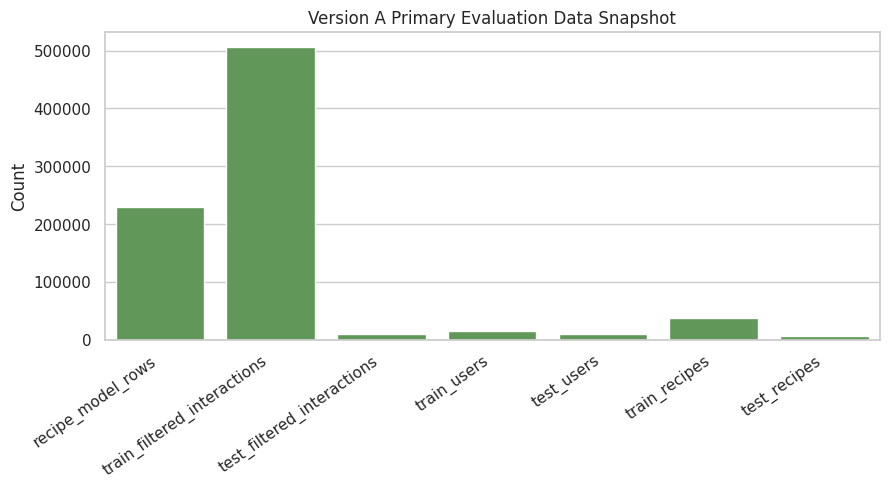

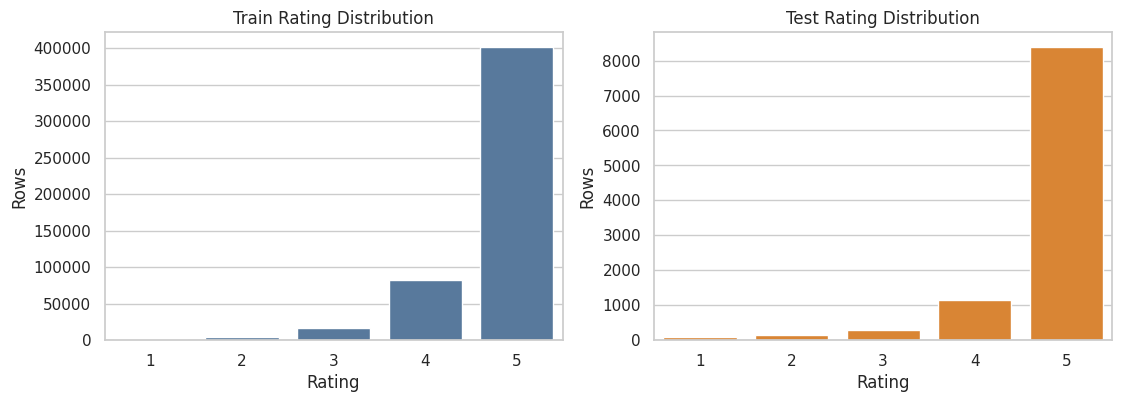

In [8]:
overview_rows = [
    {"metric": "recipe_model_rows", "value": len(recipes)},
    {"metric": "train_filtered_interactions", "value": len(train)},
    {"metric": "test_filtered_interactions", "value": len(test)},
    {"metric": "train_users", "value": train["user_id"].nunique()},
    {"metric": "test_users", "value": test["user_id"].nunique()},
    {"metric": "train_recipes", "value": train["recipe_id"].nunique()},
    {"metric": "test_recipes", "value": test["recipe_id"].nunique()},
]
overview = pd.DataFrame(overview_rows)
display(overview)

plt.figure(figsize=(10, 4))
sns.barplot(data=overview, x="metric", y="value", color="#59A14F")
plt.xticks(rotation=35, ha="right")
plt.title("Version A Primary Evaluation Data Snapshot")
plt.ylabel("Count")
plt.xlabel("")
savefig("version_a_primary_data_snapshot.png")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(data=train, x="rating", ax=axes[0], color="#4C78A8")
axes[0].set_title("Train Rating Distribution")
sns.countplot(data=test, x="rating", ax=axes[1], color="#F58518")
axes[1].set_title("Test Rating Distribution")
for ax in axes:
    ax.set_xlabel("Rating")
    ax.set_ylabel("Rows")
savefig("version_a_train_test_rating_distribution.png")
plt.show()

## Indexes, Candidate Sets, and Evaluation Users

This section builds the shared structures used by all recommenders. The default candidate catalog is recipes that appear in the filtered training split. This keeps Version A comparable with the collaborative-filtering track.

In [9]:
recipe_id_array = recipes["id"].to_numpy(dtype=np.int64)
recipe_id_to_index = {int(recipe_id): idx for idx, recipe_id in enumerate(recipe_id_array)}
index_to_recipe_id = {idx: int(recipe_id) for idx, recipe_id in enumerate(recipe_id_array)}

train_recipe_ids = set(train["recipe_id"].unique().tolist())
primary_candidate_indices = np.array(
    [recipe_id_to_index[rid] for rid in train_recipe_ids if rid in recipe_id_to_index],
    dtype=np.int64,
)
primary_candidate_recipe_ids = recipe_id_array[primary_candidate_indices]

train_seen_by_user = train.groupby("user_id")["recipe_id"].apply(lambda s: set(map(int, s))).to_dict()
test_truth_by_user = test.groupby("user_id")["recipe_id"].apply(lambda s: set(map(int, s))).to_dict()
train_rating_by_user = {
    int(user_id): group[["recipe_id", "rating"]].copy()
    for user_id, group in train.groupby("user_id")
}

positive_train_by_user = {
    user_id: frame[frame["rating"] >= CONFIG.positive_threshold].sort_values("rating", ascending=False)
    for user_id, frame in train_rating_by_user.items()
}

all_eval_users = np.array(sorted(test_truth_by_user.keys()), dtype=np.int64)
if CONFIG.fast_dev_mode and len(all_eval_users) > CONFIG.eval_user_sample_size:
    eval_users = np.sort(rng.choice(all_eval_users, size=CONFIG.eval_user_sample_size, replace=False))
else:
    eval_users = all_eval_users

print("Candidate recipes:", len(primary_candidate_indices))
print("All test users:", len(all_eval_users))
print("Users selected for this run:", len(eval_users))

Candidate recipes: 38636
All test users: 10069
Users selected for this run: 10069


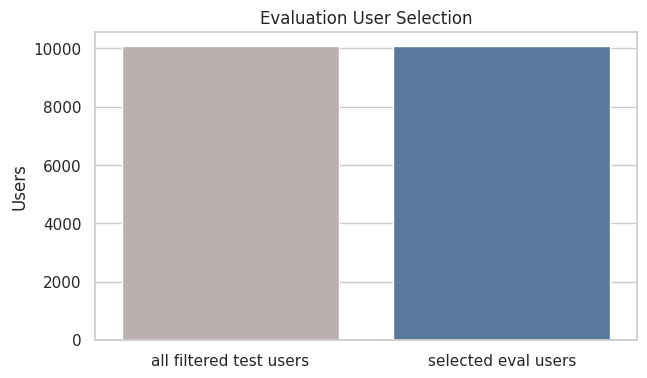

In [10]:
def plot_eval_user_sample() -> None:
    sample_info = pd.DataFrame({
        "group": ["all filtered test users", "selected eval users"],
        "users": [len(all_eval_users), len(eval_users)],
    })
    plt.figure(figsize=(7, 4))
    sns.barplot(data=sample_info, x="group", y="users", palette=["#BAB0AC", "#4C78A8"])
    plt.title("Evaluation User Selection")
    plt.xlabel("")
    plt.ylabel("Users")
    savefig("version_a_eval_user_selection.png")
    plt.show()

plot_eval_user_sample()

## Metrics and Generic Evaluation Loop

For the filtered temporal split, each user normally has one held-out recipe. The metric functions still support multiple held-out recipes per user.

In [11]:
def dcg_at_k(recommended: list[int], truth: set[int], k: int) -> float:
    score = 0.0
    for rank, recipe_id in enumerate(recommended[:k], start=1):
        if recipe_id in truth:
            score += 1.0 / math.log2(rank + 1)
    return score


def ideal_dcg_at_k(truth_count: int, k: int) -> float:
    return sum(1.0 / math.log2(rank + 1) for rank in range(1, min(truth_count, k) + 1))


def user_metrics(recommended: list[int], truth: set[int], k: int) -> dict[str, float]:
    rec_k = recommended[:k]
    if not truth:
        return {"precision": 0.0, "recall": 0.0, "ndcg": 0.0, "hit": 0.0, "hit_rank": np.nan}
    hits = [recipe_id for recipe_id in rec_k if recipe_id in truth]
    hit_rank = next((rank for rank, recipe_id in enumerate(rec_k, start=1) if recipe_id in truth), np.nan)
    idcg = ideal_dcg_at_k(len(truth), k)
    return {
        "precision": len(hits) / k,
        "recall": len(hits) / len(truth),
        "ndcg": dcg_at_k(rec_k, truth, k) / idcg if idcg > 0 else 0.0,
        "hit": float(len(hits) > 0),
        "hit_rank": hit_rank,
    }


def evaluate_recommender(
    model: Any,
    model_id: str,
    model_name: str,
    users: Iterable[int],
    k_values: tuple[int, ...] = CONFIG.k_values,
    split_name: str = "filtered_temporal_sample",
    keep_recommendations: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    max_k = max(k_values)
    users = list(map(int, users))
    per_user_rows: list[dict[str, Any]] = []
    rec_rows: list[dict[str, Any]] = []
    recommended_catalog_by_k: dict[int, set[int]] = {int(k): set() for k in k_values}
    errors = 0

    start = now()
    for user_id in tqdm(users, desc=f"Evaluating {model_id}", leave=True):
        truth = test_truth_by_user.get(user_id, set())
        if not truth:
            continue
        try:
            recs = model.recommend(user_id=user_id, n=max_k)
        except Exception as exc:
            errors += 1
            continue

        if recs is None or recs.empty:
            recommended_ids: list[int] = []
        else:
            recommended_ids = recs["recipe_id"].astype(int).head(max_k).tolist()
        for k in k_values:
            recommended_catalog_by_k[int(k)].update(recommended_ids[:int(k)])

        for k in k_values:
            metrics = user_metrics(recommended_ids, truth, k)
            per_user_rows.append({
                "model_id": model_id,
                "model_name": model_name,
                "split": split_name,
                "user_id": user_id,
                "k": k,
                **metrics,
            })

        if keep_recommendations and recs is not None and not recs.empty:
            for rank, row in recs.head(max_k).reset_index(drop=True).iterrows():
                rec_rows.append({
                    "model_id": model_id,
                    "model_name": model_name,
                    "split": split_name,
                    "user_id": user_id,
                    "rank": rank + 1,
                    "recipe_id": int(row["recipe_id"]),
                    "score": float(row.get("score", row.get("final_score", row.get("content_score", np.nan)))),
                    "name": row.get("name", ""),
                    "minutes": row.get("minutes", np.nan),
                    "is_test_hit": int(int(row["recipe_id"]) in truth),
                    "reason": row.get("reason", ""),
                })

    elapsed = time.perf_counter() - start
    per_user = pd.DataFrame(per_user_rows)
    rec_df = pd.DataFrame(rec_rows)

    if per_user.empty:
        summary = pd.DataFrame([{
            "model_id": model_id,
            "model_name": model_name,
            "split": split_name,
            "k": k,
            "evaluated_users": 0,
            "precision_at_k": 0.0,
            "recall_at_k": 0.0,
            "ndcg_at_k": 0.0,
            "hit_rate_at_k": 0.0,
            "catalog_coverage_at_k": 0.0,
            "recommend_seconds_total": elapsed,
            "recommend_seconds_per_user": np.nan,
            "errors": errors,
        } for k in k_values])
    else:
        summary_rows = []
        for k, group in per_user.groupby("k"):
            k_int = int(k)
            catalog_at_k = recommended_catalog_by_k.get(k_int, set())
            summary_rows.append({
                "model_id": model_id,
                "model_name": model_name,
                "split": split_name,
                "k": k_int,
                "evaluated_users": int(group["user_id"].nunique()),
                "precision_at_k": group["precision"].mean(),
                "recall_at_k": group["recall"].mean(),
                "ndcg_at_k": group["ndcg"].mean(),
                "hit_rate_at_k": group["hit"].mean(),
                "catalog_coverage_at_k": len(catalog_at_k) / max(1, len(primary_candidate_recipe_ids)),
                "recommend_seconds_total": elapsed,
                "recommend_seconds_per_user": elapsed / max(1, group["user_id"].nunique()),
                "errors": errors,
            })
        summary = pd.DataFrame(summary_rows)

    log_phase(f"evaluate {model_id}", start, users=len(users), errors=errors)
    return summary, per_user, rec_df

In [12]:
def plot_metric_bars(metrics_df: pd.DataFrame, k: int = 10, title: str = "Model Metrics") -> None:
    if metrics_df.empty:
        print("No metrics to plot.")
        return
    metric_cols = ["precision_at_k", "recall_at_k", "ndcg_at_k", "hit_rate_at_k", "catalog_coverage_at_k"]
    plot_df = metrics_df[metrics_df["k"] == k].melt(
        id_vars=["model_id", "model_name"],
        value_vars=[col for col in metric_cols if col in metrics_df.columns],
        var_name="metric",
        value_name="value",
    )
    plt.figure(figsize=(12, 5))
    sns.barplot(data=plot_df, x="metric", y="value", hue="model_id")
    plt.title(f"{title} @ {k}")
    plt.xlabel("")
    plt.ylabel("Value")
    plt.xticks(rotation=25, ha="right")
    plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
    savefig(f"version_a_model_metrics_at_{k}.png")
    plt.show()


def plot_runtime_vs_quality(metrics_df: pd.DataFrame, k: int = 10) -> None:
    if metrics_df.empty:
        return
    df = metrics_df[metrics_df["k"] == k].copy()
    plt.figure(figsize=(8, 5))
    sns.scatterplot(
        data=df,
        x="recommend_seconds_per_user",
        y="ndcg_at_k",
        size="catalog_coverage_at_k",
        hue="model_id",
        sizes=(80, 400),
    )
    for _, row in df.iterrows():
        plt.text(row["recommend_seconds_per_user"], row["ndcg_at_k"], f" {row['model_id']}", va="center")
    plt.title(f"Quality vs Runtime @ {k}")
    plt.xlabel("Recommendation seconds per user")
    plt.ylabel(f"NDCG@{k}")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    savefig(f"version_a_quality_vs_runtime_at_{k}.png")
    plt.show()


def plot_hit_rank_distribution(per_user_df: pd.DataFrame, k: int = 10) -> None:
    if per_user_df.empty:
        return
    df = per_user_df[(per_user_df["k"] == k) & per_user_df["hit_rank"].notna()].copy()
    if df.empty:
        print("No hits to plot yet.")
        return
    plt.figure(figsize=(10, 4))
    sns.histplot(data=df, x="hit_rank", hue="model_id", discrete=True, multiple="dodge", shrink=0.8)
    plt.title(f"Held-out Recipe Hit Rank Distribution @ {k}")
    plt.xlabel("Rank of first hit")
    plt.ylabel("Users")
    savefig(f"version_a_hit_rank_distribution_at_{k}.png")
    plt.show()

# A0: Bayesian Popularity Baseline

This is the strongest non-personalized baseline. It uses only training interactions and avoids over-rewarding recipes with tiny rating counts.

In [13]:
class BayesianPopularityRecommender:
    def __init__(
        self,
        recipes: pd.DataFrame,
        candidate_indices: np.ndarray,
        train_seen_by_user: dict[int, set[int]],
        m: int = 20,
    ):
        self.recipes = recipes.reset_index(drop=True)
        self.candidate_indices = np.array(candidate_indices, dtype=np.int64)
        self.train_seen_by_user = train_seen_by_user
        self.m = m
        self.recipe_id_array = self.recipes["id"].to_numpy(dtype=np.int64)
        self.recipe_id_to_index = {int(rid): idx for idx, rid in enumerate(self.recipe_id_array)}
        self.score_vector = np.full(len(self.recipes), -np.inf, dtype=np.float32)
        self.popularity_table: pd.DataFrame | None = None
        self.global_mean = np.nan

    def fit(self, train_interactions: pd.DataFrame) -> "BayesianPopularityRecommender":
        start = now()
        stats = (
            train_interactions.groupby("recipe_id")["rating"]
            .agg(rating_count="count", rating_mean="mean")
            .reset_index()
        )
        self.global_mean = float(train_interactions["rating"].mean())
        stats["bayesian_score"] = (
            (stats["rating_count"] / (stats["rating_count"] + self.m)) * stats["rating_mean"]
            + (self.m / (stats["rating_count"] + self.m)) * self.global_mean
        )
        self.popularity_table = stats.sort_values("bayesian_score", ascending=False).reset_index(drop=True)

        for row in stats.itertuples(index=False):
            idx = self.recipe_id_to_index.get(int(row.recipe_id))
            if idx is not None:
                self.score_vector[idx] = float(row.bayesian_score)

        log_phase(f"fit A0 bayesian popularity m={self.m}", start, recipes=len(stats))
        return self

    def recommend(
        self,
        user_id: int,
        n: int = 10,
        max_minutes: int | None = None,
        require_quick: bool = False,
        exclude_terms: tuple[str, ...] = (),
    ) -> pd.DataFrame:
        scores = self.score_vector[self.candidate_indices].copy()
        candidate_indices = self.candidate_indices.copy()

        seen = self.train_seen_by_user.get(int(user_id), set())
        if seen:
            seen_indices = {self.recipe_id_to_index[rid] for rid in seen if rid in self.recipe_id_to_index}
            seen_mask = np.isin(candidate_indices, list(seen_indices))
            scores[seen_mask] = -np.inf

        if max_minutes is not None:
            minutes = self.recipes.iloc[candidate_indices]["minutes"].to_numpy(dtype=float)
            scores[minutes > max_minutes] = -np.inf

        if require_quick and "quick_recipe" in self.recipes.columns:
            quick = self.recipes.iloc[candidate_indices]["quick_recipe"].to_numpy(dtype=bool)
            scores[~quick] = -np.inf

        if exclude_terms:
            text = self.recipes.iloc[candidate_indices]["combined_text"].fillna("").str.lower()
            excluded = np.zeros(len(candidate_indices), dtype=bool)
            for term in exclude_terms:
                excluded |= text.str.contains(str(term).lower(), regex=False).to_numpy()
            scores[excluded] = -np.inf

        finite = np.isfinite(scores)
        if not finite.any():
            return pd.DataFrame(columns=["recipe_id", "score", "name", "minutes", "reason"])

        top_n = min(n, int(finite.sum()))
        local_top = np.argpartition(scores, -top_n)[-top_n:]
        local_top = local_top[np.argsort(scores[local_top])[::-1]]
        recipe_indices = candidate_indices[local_top]

        recs = self.recipes.iloc[recipe_indices][["id", "name", "minutes", "quick_recipe", "history_bucket"]].copy()
        recs = recs.rename(columns={"id": "recipe_id"})
        recs["score"] = scores[local_top]
        recs["reason"] = f"high train-only Bayesian popularity score, m={self.m}"
        return recs.reset_index(drop=True)

In [14]:
all_metrics: list[pd.DataFrame] = []
all_per_user: list[pd.DataFrame] = []
all_recommendations: list[pd.DataFrame] = []
all_tuning_rows: list[pd.DataFrame] = []

popularity_tuning_results = []

for m in CONFIG.popularity_m_values:
    model = BayesianPopularityRecommender(recipes, primary_candidate_indices, train_seen_by_user, m=m).fit(train)
    summary, per_user, recs = evaluate_recommender(
        model,
        model_id=f"A0_m{m}",
        model_name=f"Bayesian popularity m={m}",
        users=eval_users,
        split_name="filtered_temporal_sample" if CONFIG.fast_dev_mode else "filtered_temporal",
    )
    summary["tuned_m"] = m
    popularity_tuning_results.append(summary)

popularity_tuning_df = pd.concat(popularity_tuning_results, ignore_index=True)
display(popularity_tuning_df)

best_popularity_row = popularity_tuning_df[popularity_tuning_df["k"] == CONFIG.primary_k].sort_values(
    ["ndcg_at_k", "recall_at_k", "precision_at_k"], ascending=False
).iloc[0]
BEST_POPULARITY_M = int(best_popularity_row["tuned_m"])
print("Best popularity m:", BEST_POPULARITY_M)

best_popularity_model = BayesianPopularityRecommender(
    recipes, primary_candidate_indices, train_seen_by_user, m=BEST_POPULARITY_M
).fit(train)
best_pop_summary, best_pop_per_user, best_pop_recs = evaluate_recommender(
    best_popularity_model,
    model_id="A0",
    model_name="Bayesian popularity baseline",
    users=eval_users,
    split_name="filtered_temporal_sample" if CONFIG.fast_dev_mode else "filtered_temporal",
)

all_metrics.append(best_pop_summary)
all_per_user.append(best_pop_per_user)
all_recommendations.append(best_pop_recs)
all_tuning_rows.append(popularity_tuning_df.assign(tuning_family="popularity_m"))

# Save A0 trained scoring artifacts for reuse.
save_numpy_artifact(best_popularity_model.score_vector, "a0_bayesian_score_vector.npy")
if best_popularity_model.popularity_table is not None:
    best_popularity_model.popularity_table.to_csv(ARTIFACT_DIR / "a0_bayesian_popularity_table.csv", index=False)
save_json_artifact(
    {
        "model_id": "A0",
        "model_name": "Bayesian popularity baseline",
        "best_m": BEST_POPULARITY_M,
        "global_mean_rating": best_popularity_model.global_mean,
    },
    "a0_bayesian_popularity_metadata.json",
)

fit A0 bayesian popularity m=5: 0.08s


Evaluating A0_m5:   0%|          | 0/10069 [00:00<?, ?it/s]

evaluate A0_m5: 35.66s
fit A0 bayesian popularity m=10: 0.08s


Evaluating A0_m10:   0%|          | 0/10069 [00:00<?, ?it/s]

evaluate A0_m10: 35.40s
fit A0 bayesian popularity m=20: 0.08s


...

,model_id,model_name,split,k,evaluated_users,precision_at_k,recall_at_k,ndcg_at_k,hit_rate_at_k,catalog_coverage_at_k,recommend_seconds_total,recommend_seconds_per_user,errors,tuned_m
0,A0_m5,Bayesian popularity m=5,filtered_temporal,5,10069,0.000159,0.000795,0.000559,0.000795,0.000233,35.402503,0.003516,0,5
1,A0_m5,Bayesian popularity m=5,filtered_temporal,10,10069,0.000149,0.001490,0.000787,0.001490,0.000440,35.402503,0.003516,0,5
2,A0_m10,Bayesian popularity m=10,filtered_temporal,5,10069,0.000298,0.001490,0.000857,0.001490,0.000181,35.140367,0.003490,0,10
3,A0_m10,Bayesian popularity m=10,filtered_temporal,10,10069,0.000278,0.002781,0.001264,0.002781,0.000362,35.140367,0.003490,0,10
4,A0_m20,Bayesian popularity m=20,filtered_temporal,5,10069,0.000338,0.001688,0.001141,0.001688,0.000207,35.176412,0.003494,0,20
5,A0_m20,Bayesian popularity m=20,filtered_temporal,10,10069,0.000288,0.002880,0.001539,0.002880,0.000388,35.176412,0.003494,0,20
6,A0_m50,Bayesian popularity m=50,filtered_temporal,5,10069,0.000655,0.003277,0.001906,0.003277,0.000285,35.165620,0.003492,0,50
7,A0_m50,Bayesian popularity m=50,filtered_temporal,10,10069,0.000834,0.008342,0.003471,0.008342,0.000492,35.165620,0.003492,0,50
8,A0_m100,Bayesian popularity m=100,filtered_temporal,5,10069,0.001251,0.006257,0.003434,0.006257,0.000311,35.171871,0.003493,0,100
9,A0_m100,Bayesian popularity m=100,filtered_temporal,10,10069,0.001003,0.010031,0.004618,0.010031,0.000621,35.171871,0.003493,0,100


Best popularity m: 100
fit A0 bayesian popularity m=100: 0.08s


Evaluating A0:   0%|          | 0/10069 [00:00<?, ?it/s]

evaluate A0: 35.39s


PosixPath('/content/drive/MyDrive/513/Final/Version_A/Experiments/model_artifacts/a0_bayesian_popularity_metadata.json')

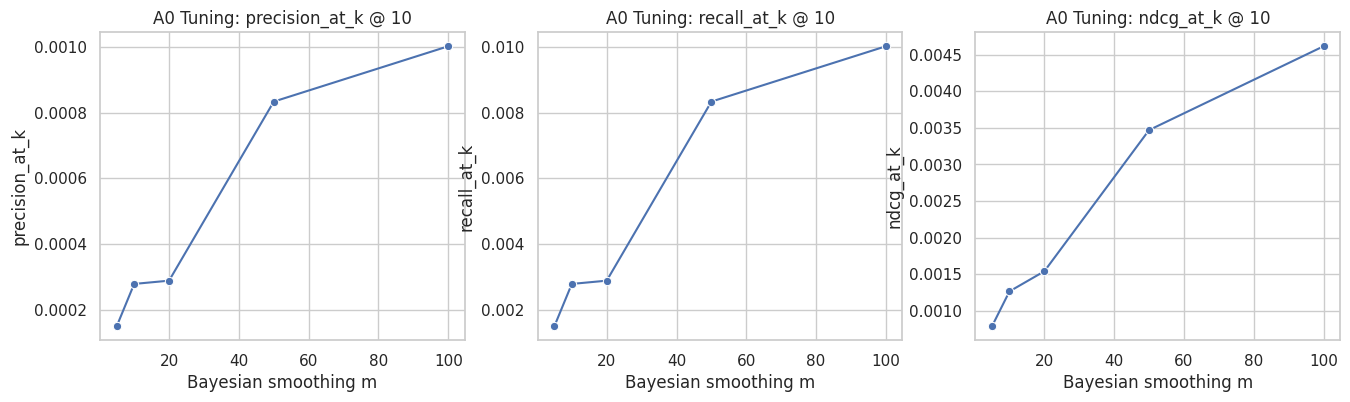

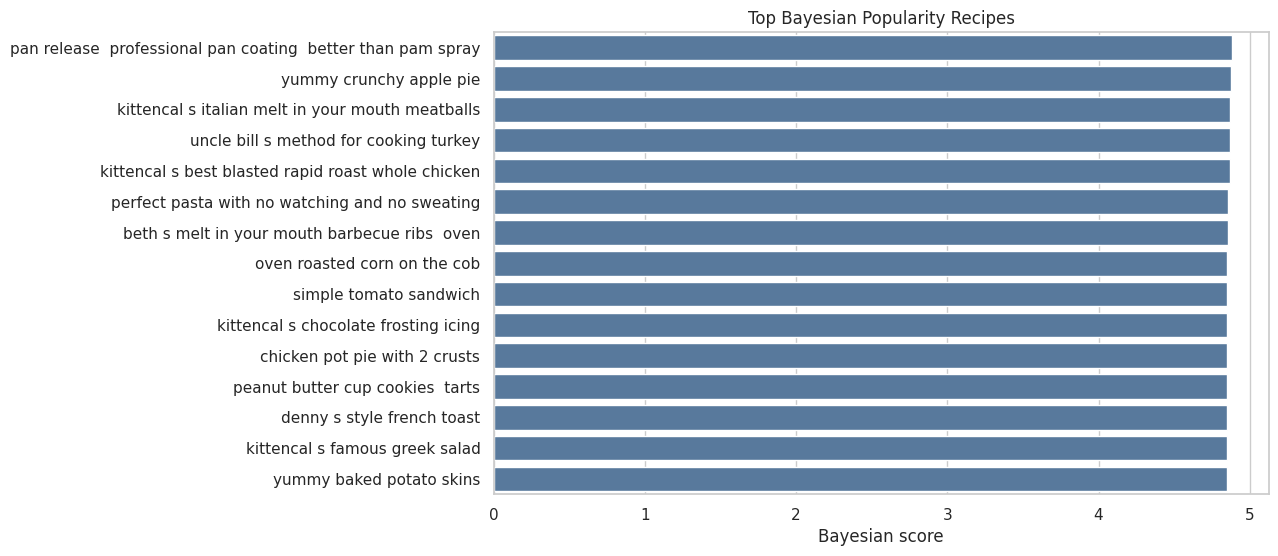

,recipe_id,name,rating_count,rating_mean,bayesian_score,minutes
0,78579,pan release professional pan coating better than pam spray,184,4.961957,4.880357,5
1,31128,yummy crunchy apple pie,306,4.921569,4.874437,70
2,69173,kittencal s italian melt in your mouth meatballs,669,4.893871,4.872590,50
3,46262,uncle bill s method for cooking turkey,130,4.976923,4.869658,330
4,221743,kittencal s best blasted rapid roast whole chicken,209,4.933014,4.867383,80
5,30358,perfect pasta with no watching and no sweating,138,4.949275,4.857233,18
6,107786,beth s melt in your mouth barbecue ribs oven,152,4.940789,4.857228,195
7,177558,oven roasted corn on the cob,171,4.923977,4.852478,30
8,98724,simple tomato sandwich,123,4.951220,4.852114,5
9,89207,kittencal s chocolate frosting icing,339,4.887906,4.851985,5


In [15]:
plot_df = popularity_tuning_df[popularity_tuning_df["k"] == CONFIG.primary_k].copy()
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric in zip(axes, ["precision_at_k", "recall_at_k", "ndcg_at_k"]):
    sns.lineplot(data=plot_df, x="tuned_m", y=metric, marker="o", ax=ax)
    ax.set_title(f"A0 Tuning: {metric} @ {CONFIG.primary_k}")
    ax.set_xlabel("Bayesian smoothing m")
    ax.set_ylabel(metric)
savefig("version_a_a0_popularity_tuning.png")
plt.show()

if best_popularity_model.popularity_table is not None:
    top_pop = best_popularity_model.popularity_table.head(15).merge(
        recipes[["id", "name", "minutes"]], left_on="recipe_id", right_on="id", how="left"
    )
    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_pop, y="name", x="bayesian_score", color="#4C78A8")
    plt.title("Top Bayesian Popularity Recipes")
    plt.xlabel("Bayesian score")
    plt.ylabel("")
    savefig("version_a_top_bayesian_popularity_recipes.png")
    plt.show()
    display(top_pop[["recipe_id", "name", "rating_count", "rating_mean", "bayesian_score", "minutes"]].head(10))

# A2 and A3: TF-IDF Content Models

A2 recommends recipes similar to a user's liked seed recipes. A3 builds one user preference vector from liked recipes and ranks candidates by cosine similarity.

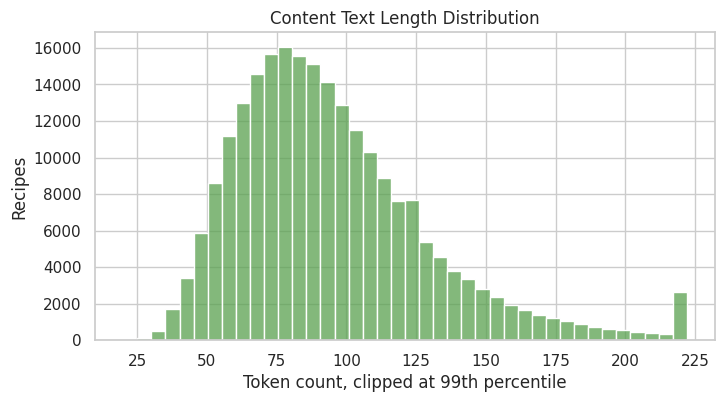

In [16]:
def prepare_content_frame(recipes: pd.DataFrame) -> pd.DataFrame:
    df = recipes.copy()
    for col in ["name", "description", "tags_text", "ingredients_text", "combined_text"]:
        if col not in df.columns:
            df[col] = ""
        df[col] = df[col].fillna("").astype(str)

    if "quick_recipe" in df.columns:
        df["quick_text"] = np.where(df["quick_recipe"].astype(bool), " quick_recipe quick_meal fast_recipe ", "")
    else:
        df["quick_text"] = ""

    # Tags and ingredients are repeated lightly because they are the most useful explainable metadata.
    df["content_text_final"] = (
        df["name"] + " "
        + df["description"] + " "
        + df["tags_text"] + " " + df["tags_text"] + " "
        + df["ingredients_text"] + " " + df["ingredients_text"] + " "
        + df["quick_text"]
    ).str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
    return df

content_recipes = prepare_content_frame(recipes)

text_lengths = content_recipes["content_text_final"].str.split().str.len()
plt.figure(figsize=(8, 4))
sns.histplot(text_lengths.clip(upper=text_lengths.quantile(0.99)), bins=40, color="#59A14F")
plt.title("Content Text Length Distribution")
plt.xlabel("Token count, clipped at 99th percentile")
plt.ylabel("Recipes")
savefig("version_a_content_text_length_distribution.png")
plt.show()

In [17]:
@dataclass
class ContentArtifacts:
    vectorizer: TfidfVectorizer
    tfidf_matrix: sp.csr_matrix
    recipes: pd.DataFrame
    candidate_indices: np.ndarray
    candidate_recipe_ids: np.ndarray


def build_tfidf_artifacts(
    recipes_for_content: pd.DataFrame,
    candidate_indices: np.ndarray,
    *,
    max_features: int = CONFIG.max_features_default,
    min_df: int = CONFIG.min_df_default,
    max_df: float = CONFIG.max_df_default,
    ngram_range: tuple[int, int] = (1, 1),
) -> ContentArtifacts:
    start = now()
    vectorizer = TfidfVectorizer(
        stop_words="english",
        max_features=max_features,
        min_df=min_df,
        max_df=max_df,
        ngram_range=ngram_range,
        dtype=np.float32,
        sublinear_tf=True,
        norm="l2",
    )
    tfidf_matrix = vectorizer.fit_transform(recipes_for_content["content_text_final"])
    tfidf_matrix = tfidf_matrix.tocsr()
    candidate_recipe_ids = recipes_for_content.iloc[candidate_indices]["id"].to_numpy(dtype=np.int64)
    log_phase(
        f"fit TF-IDF max_features={max_features} min_df={min_df} ngram={ngram_range}",
        start,
        features=len(vectorizer.get_feature_names_out()),
        nnz=tfidf_matrix.nnz,
    )
    return ContentArtifacts(vectorizer, tfidf_matrix, recipes_for_content, candidate_indices, candidate_recipe_ids)


def top_indices_from_scores(scores: np.ndarray, n: int) -> np.ndarray:
    finite = np.isfinite(scores)
    if not finite.any():
        return np.array([], dtype=np.int64)
    top_n = min(n, int(finite.sum()))
    local_top = np.argpartition(scores, -top_n)[-top_n:]
    return local_top[np.argsort(scores[local_top])[::-1]]


def get_liked_history(user_id: int) -> pd.DataFrame:
    positives = positive_train_by_user.get(int(user_id))
    if positives is not None and not positives.empty:
        return positives.sort_values("rating", ascending=False).head(CONFIG.top_seed_recipes)
    fallback = train_rating_by_user.get(int(user_id), pd.DataFrame(columns=["recipe_id", "rating"]))
    return fallback.sort_values("rating", ascending=False).head(CONFIG.top_seed_recipes)

In [18]:
class ItemSimilarityContentRecommender:
    def __init__(
        self,
        artifacts: ContentArtifacts,
        train_seen_by_user: dict[int, set[int]],
        fallback_model: BayesianPopularityRecommender,
        candidate_pool_size: int = CONFIG.item_similarity_pool_size,
    ):
        self.artifacts = artifacts
        self.train_seen_by_user = train_seen_by_user
        self.fallback_model = fallback_model
        self.candidate_pool_size = candidate_pool_size
        self.recipe_id_to_index = {int(rid): idx for idx, rid in enumerate(artifacts.recipes["id"].to_numpy(dtype=np.int64))}

    def recommend(self, user_id: int, n: int = 10) -> pd.DataFrame:
        liked = get_liked_history(user_id)
        if liked.empty:
            return self.fallback_model.recommend(user_id=user_id, n=n)

        seen = self.train_seen_by_user.get(int(user_id), set())
        aggregate: dict[int, list[float]] = {}

        for row in liked.itertuples(index=False):
            seed_idx = self.recipe_id_to_index.get(int(row.recipe_id))
            if seed_idx is None:
                continue
            sims = self.artifacts.tfidf_matrix[seed_idx].dot(
                self.artifacts.tfidf_matrix[self.artifacts.candidate_indices].T
            ).toarray().ravel()
            local_top = top_indices_from_scores(sims, self.candidate_pool_size)
            for local_idx in local_top:
                rec_recipe_id = int(self.artifacts.candidate_recipe_ids[local_idx])
                if rec_recipe_id in seen or rec_recipe_id == int(row.recipe_id):
                    continue
                aggregate.setdefault(rec_recipe_id, []).append(float(sims[local_idx]))

        if not aggregate:
            return self.fallback_model.recommend(user_id=user_id, n=n)

        rows = [
            {"recipe_id": rid, "content_score": float(np.mean(scores)), "seed_matches": len(scores)}
            for rid, scores in aggregate.items()
        ]
        df = pd.DataFrame(rows).sort_values(["content_score", "seed_matches"], ascending=False).head(n)
        recs = df.merge(
            self.artifacts.recipes[["id", "name", "minutes", "quick_recipe", "history_bucket"]],
            left_on="recipe_id",
            right_on="id",
            how="left",
        ).drop(columns=["id"])
        recs["score"] = recs["content_score"]
        recs["reason"] = "similar to liked training recipes by TF-IDF metadata"
        return recs.reset_index(drop=True)


class UserProfileContentRecommender:
    def __init__(
        self,
        artifacts: ContentArtifacts,
        train_seen_by_user: dict[int, set[int]],
        fallback_model: BayesianPopularityRecommender,
    ):
        self.artifacts = artifacts
        self.train_seen_by_user = train_seen_by_user
        self.fallback_model = fallback_model
        self.recipe_id_to_index = {int(rid): idx for idx, rid in enumerate(artifacts.recipes["id"].to_numpy(dtype=np.int64))}

    def build_user_profile(self, user_id: int) -> sp.csr_matrix | None:
        liked = get_liked_history(user_id)
        if liked.empty:
            return None
        liked_indices = []
        weights = []
        for row in liked.itertuples(index=False):
            idx = self.recipe_id_to_index.get(int(row.recipe_id))
            if idx is not None:
                liked_indices.append(idx)
                weights.append(max(float(row.rating) - CONFIG.positive_threshold + 1.0, 0.25))
        if not liked_indices:
            return None
        matrix = self.artifacts.tfidf_matrix[liked_indices]
        weight_arr = np.asarray(weights, dtype=np.float32)
        profile = matrix.multiply(weight_arr[:, None]).sum(axis=0)
        profile = sp.csr_matrix(profile)
        profile = normalize(profile, norm="l2", copy=False)
        return profile

    def score_candidates(self, user_id: int) -> tuple[np.ndarray, np.ndarray]:
        profile = self.build_user_profile(user_id)
        if profile is None:
            return np.array([], dtype=np.int64), np.array([], dtype=np.float32)
        scores = profile.dot(self.artifacts.tfidf_matrix[self.artifacts.candidate_indices].T).toarray().ravel()
        seen = self.train_seen_by_user.get(int(user_id), set())
        if seen:
            seen_candidate_mask = np.isin(self.artifacts.candidate_recipe_ids, list(seen))
            scores[seen_candidate_mask] = -np.inf
        return self.artifacts.candidate_indices, scores

    def recommend(self, user_id: int, n: int = 10) -> pd.DataFrame:
        candidate_indices, scores = self.score_candidates(user_id)
        if candidate_indices.size == 0 or not np.isfinite(scores).any():
            return self.fallback_model.recommend(user_id=user_id, n=n)
        local_top = top_indices_from_scores(scores, n)
        recipe_indices = candidate_indices[local_top]
        recs = self.artifacts.recipes.iloc[recipe_indices][["id", "name", "minutes", "quick_recipe", "history_bucket"]].copy()
        recs = recs.rename(columns={"id": "recipe_id"})
        recs["content_score"] = scores[local_top]
        recs["score"] = recs["content_score"]
        recs["reason"] = "close to the user's liked-recipe TF-IDF profile"
        return recs.reset_index(drop=True)

In [19]:
content_tuning_results = []
content_artifact_cache: dict[str, ContentArtifacts] = {}

for config_id, tfidf_params in enumerate(CONFIG.tfidf_tuning_grid, start=1):
    artifact_key = f"tfidf_{config_id}"
    artifacts = build_tfidf_artifacts(content_recipes, primary_candidate_indices, **tfidf_params)
    content_artifact_cache[artifact_key] = artifacts

    profile_model = UserProfileContentRecommender(artifacts, train_seen_by_user, best_popularity_model)
    summary, per_user, recs = evaluate_recommender(
        profile_model,
        model_id=f"A3_tune{config_id}",
        model_name=f"User-profile content {tfidf_params}",
        users=eval_users,
        split_name="filtered_temporal_sample" if CONFIG.fast_dev_mode else "filtered_temporal",
        keep_recommendations=False,
    )
    for key, value in tfidf_params.items():
        summary[key] = str(value)
    summary["artifact_key"] = artifact_key
    content_tuning_results.append(summary)

content_tuning_df = pd.concat(content_tuning_results, ignore_index=True)
display(content_tuning_df)

best_content_row = content_tuning_df[content_tuning_df["k"] == CONFIG.primary_k].sort_values(
    ["ndcg_at_k", "recall_at_k", "precision_at_k"], ascending=False
).iloc[0]
BEST_CONTENT_ARTIFACT_KEY = str(best_content_row["artifact_key"])
print("Best TF-IDF artifact:", BEST_CONTENT_ARTIFACT_KEY)

best_artifacts = content_artifact_cache[BEST_CONTENT_ARTIFACT_KEY]
all_tuning_rows.append(content_tuning_df.assign(tuning_family="tfidf_user_profile"))

# Save trained TF-IDF content artifacts.
save_pickle_artifact(best_artifacts.vectorizer, "tfidf_vectorizer.pkl")
save_sparse_artifact(best_artifacts.tfidf_matrix, "tfidf_matrix.npz")
save_numpy_artifact(best_artifacts.candidate_indices, "tfidf_candidate_indices.npy")
save_numpy_artifact(best_artifacts.candidate_recipe_ids, "tfidf_candidate_recipe_ids.npy")
save_json_artifact(
    {
        "model_family": "TF-IDF content",
        "best_artifact_key": BEST_CONTENT_ARTIFACT_KEY,
        "feature_count": len(best_artifacts.vectorizer.get_feature_names_out()),
        "matrix_shape": best_artifacts.tfidf_matrix.shape,
        "matrix_nnz": int(best_artifacts.tfidf_matrix.nnz),
    },
    "tfidf_content_metadata.json",
)

fit TF-IDF max_features=10000 min_df=2 ngram=(1, 1): 15.08s


Evaluating A3_tune1:   0%|          | 0/10069 [00:00<?, ?it/s]

evaluate A3_tune1: 375.80s
fit TF-IDF max_features=20000 min_df=2 ngram=(1, 1): 14.95s


Evaluating A3_tune2:   0%|          | 0/10069 [00:00<?, ?it/s]

evaluate A3_tune2: 368.24s
fit TF-IDF max_features=30000 min_df=2 ngram=(1, 1): 15.07s


...

Evaluating A3_tune4:   0%|          | 0/10069 [00:00<?, ?it/s]

evaluate A3_tune4: 600.41s


,model_id,model_name,split,k,evaluated_users,precision_at_k,recall_at_k,ndcg_at_k,hit_rate_at_k,catalog_coverage_at_k,recommend_seconds_total,recommend_seconds_per_user,errors,max_features,min_df,ngram_range,artifact_key
0,A3_tune1,"User-profile content {'max_features': 10000, 'min_df': 2, 'ngram_range': (1, 1)}",filtered_temporal,5,10069,0.000258,0.001291,0.000739,0.001291,0.246092,375.757412,0.037318,0,10000,2,"(1, 1)",tfidf_1
1,A3_tune1,"User-profile content {'max_features': 10000, 'min_df': 2, 'ngram_range': (1, 1)}",filtered_temporal,10,10069,0.000268,0.002681,0.001191,0.002681,0.345973,375.757412,0.037318,0,10000,2,"(1, 1)",tfidf_1
2,A3_tune2,"User-profile content {'max_features': 20000, 'min_df': 2, 'ngram_range': (1, 1)}",filtered_temporal,5,10069,0.000258,0.001291,0.000752,0.001291,0.236101,368.190637,0.036567,0,20000,2,"(1, 1)",tfidf_2
3,A3_tune2,"User-profile content {'max_features': 20000, 'min_df': 2, 'ngram_range': (1, 1)}",filtered_temporal,10,10069,0.000238,0.002384,0.001125,0.002384,0.330650,368.190637,0.036567,0,20000,2,"(1, 1)",tfidf_2
4,A3_tune3,"User-profile content {'max_features': 30000, 'min_df': 2, 'ngram_range': (1, 1)}",filtered_temporal,5,10069,0.000278,0.001390,0.000803,0.001390,0.233125,401.136519,0.039839,0,30000,2,"(1, 1)",tfidf_3
5,A3_tune3,"User-profile content {'max_features': 30000, 'min_df': 2, 'ngram_range': (1, 1)}",filtered_temporal,10,10069,0.000238,0.002384,0.001140,0.002384,0.326664,401.136519,0.039839,0,30000,2,"(1, 1)",tfidf_3
6,A3_tune4,"User-profile content {'max_features': 30000, 'min_df': 3, 'ngram_range': (1, 2)}",filtered_temporal,5,10069,0.000298,0.001490,0.000948,0.001490,0.322860,600.362787,0.059625,0,30000,3,"(1, 2)",tfidf_4
7,A3_tune4,"User-profile content {'max_features': 30000, 'min_df': 3, 'ngram_range': (1, 2)}",filtered_temporal,10,10069,0.000268,0.002681,0.001321,0.002681,0.457397,600.362787,0.059625,0,30000,3,"(1, 2)",tfidf_4


Best TF-IDF artifact: tfidf_4


PosixPath('/content/drive/MyDrive/513/Final/Version_A/Experiments/model_artifacts/tfidf_content_metadata.json')

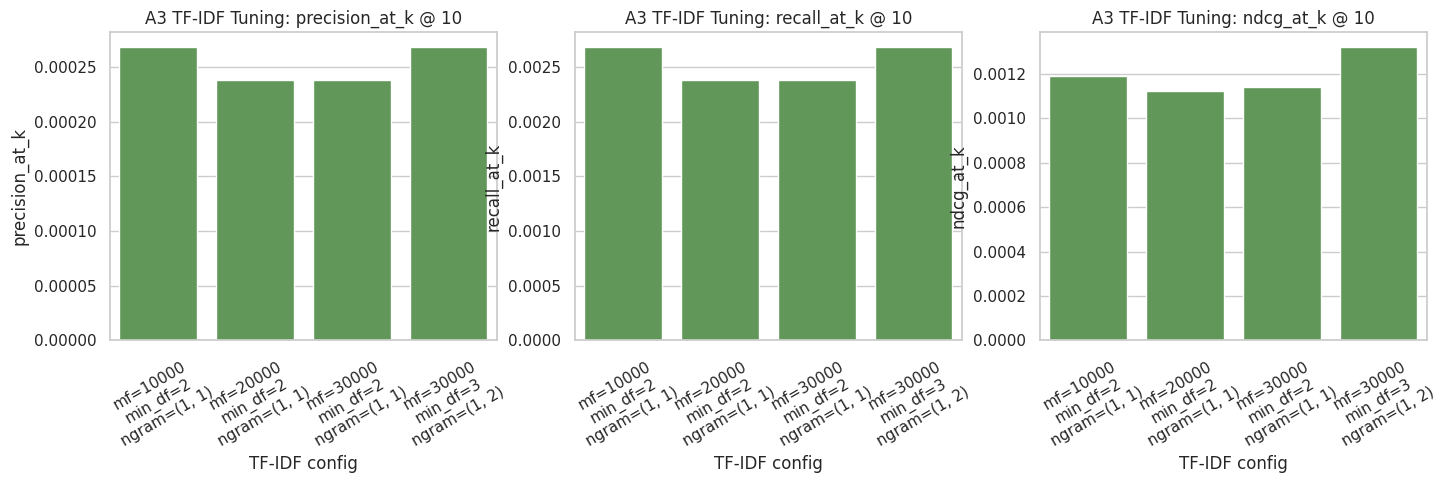

,metric,value
0,tfidf_features,3.000000e+04
1,tfidf_nonzero_entries,1.613080e+07
2,tfidf_sparsity,9.976677e-01


In [20]:
plot_df = content_tuning_df[content_tuning_df["k"] == CONFIG.primary_k].copy()
plot_df["config_label"] = plot_df.apply(
    lambda r: f"mf={r['max_features']}\nmin_df={r['min_df']}\nngram={r['ngram_range']}", axis=1
)
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, metric in zip(axes, ["precision_at_k", "recall_at_k", "ndcg_at_k"]):
    sns.barplot(data=plot_df, x="config_label", y=metric, ax=ax, color="#59A14F")
    ax.set_title(f"A3 TF-IDF Tuning: {metric} @ {CONFIG.primary_k}")
    ax.set_xlabel("TF-IDF config")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=30)
savefig("version_a_a3_tfidf_tuning.png")
plt.show()

feature_count = len(best_artifacts.vectorizer.get_feature_names_out())
nnz = best_artifacts.tfidf_matrix.nnz
sparsity = 1 - nnz / (best_artifacts.tfidf_matrix.shape[0] * best_artifacts.tfidf_matrix.shape[1])
feature_info = pd.DataFrame([
    {"metric": "tfidf_features", "value": feature_count},
    {"metric": "tfidf_nonzero_entries", "value": nnz},
    {"metric": "tfidf_sparsity", "value": sparsity},
])
display(feature_info)

In [21]:
item_similarity_model = ItemSimilarityContentRecommender(
    best_artifacts,
    train_seen_by_user,
    best_popularity_model,
    candidate_pool_size=CONFIG.item_similarity_pool_size,
)
profile_content_model = UserProfileContentRecommender(
    best_artifacts,
    train_seen_by_user,
    best_popularity_model,
)

item_summary, item_per_user, item_recs = evaluate_recommender(
    item_similarity_model,
    model_id="A2",
    model_name="TF-IDF item-to-item content",
    users=eval_users,
    split_name="filtered_temporal_sample" if CONFIG.fast_dev_mode else "filtered_temporal",
)
profile_summary, profile_per_user, profile_recs = evaluate_recommender(
    profile_content_model,
    model_id="A3",
    model_name="User-profile TF-IDF content",
    users=eval_users,
    split_name="filtered_temporal_sample" if CONFIG.fast_dev_mode else "filtered_temporal",
)

all_metrics.extend([item_summary, profile_summary])
all_per_user.extend([item_per_user, profile_per_user])
all_recommendations.extend([item_recs, profile_recs])

display(pd.concat([item_summary, profile_summary], ignore_index=True))

Evaluating A2:   0%|          | 0/10069 [00:00<?, ?it/s]

evaluate A2: 2876.50s


Evaluating A3:   0%|          | 0/10069 [00:00<?, ?it/s]

evaluate A3: 582.96s


,model_id,model_name,split,k,evaluated_users,precision_at_k,recall_at_k,ndcg_at_k,hit_rate_at_k,catalog_coverage_at_k,recommend_seconds_total,recommend_seconds_per_user,errors
0,A2,TF-IDF item-to-item content,filtered_temporal,5,10069,0.000258,0.001291,0.000848,0.001291,0.306191,2876.173422,0.285646,0
1,A2,TF-IDF item-to-item content,filtered_temporal,10,10069,0.000218,0.002185,0.001134,0.002185,0.448520,2876.173422,0.285646,0
2,A3,User-profile TF-IDF content,filtered_temporal,5,10069,0.000298,0.001490,0.000948,0.001490,0.322860,582.667159,0.057867,0
3,A3,User-profile TF-IDF content,filtered_temporal,10,10069,0.000268,0.002681,0.001321,0.002681,0.457397,582.667159,0.057867,0


# A4: Content Plus Popularity Reranker

A4 is the main Version A candidate. It starts with personalized content candidates, then reranks them with train-only Bayesian popularity and a small practical bonus.

In [22]:
class ContentPopularityReranker:
    def __init__(
        self,
        content_model: UserProfileContentRecommender,
        popularity_model: BayesianPopularityRecommender,
        recipes: pd.DataFrame,
        content_weight: float = 0.70,
        popularity_weight: float = 0.25,
        practical_weight: float = 0.05,
        rerank_pool_size: int = CONFIG.rerank_pool_size,
    ):
        self.content_model = content_model
        self.popularity_model = popularity_model
        self.recipes = recipes.reset_index(drop=True)
        self.content_weight = content_weight
        self.popularity_weight = popularity_weight
        self.practical_weight = practical_weight
        self.rerank_pool_size = rerank_pool_size
        self.recipe_id_to_index = {int(rid): idx for idx, rid in enumerate(self.recipes["id"].to_numpy(dtype=np.int64))}

    def practical_bonus(self, recipe_indices: np.ndarray) -> np.ndarray:
        bonus = np.zeros(len(recipe_indices), dtype=np.float32)
        if "quick_recipe" in self.recipes.columns:
            bonus += self.recipes.iloc[recipe_indices]["quick_recipe"].to_numpy(dtype=bool).astype(np.float32) * 0.5
        if "minutes" in self.recipes.columns:
            minutes = self.recipes.iloc[recipe_indices]["minutes"].fillna(9999).to_numpy(dtype=float)
            bonus += (minutes <= 45).astype(np.float32) * 0.5
        return bonus

    def recommend(self, user_id: int, n: int = 10) -> pd.DataFrame:
        candidate_indices, content_scores = self.content_model.score_candidates(user_id)
        if candidate_indices.size == 0 or not np.isfinite(content_scores).any():
            return self.popularity_model.recommend(user_id=user_id, n=n)

        pool_local = top_indices_from_scores(content_scores, self.rerank_pool_size)
        recipe_indices = candidate_indices[pool_local]
        recipe_ids = self.recipes.iloc[recipe_indices]["id"].to_numpy(dtype=np.int64)

        content_norm = minmax(content_scores[pool_local])
        popularity_scores = self.popularity_model.score_vector[recipe_indices]
        popularity_norm = minmax(popularity_scores)
        practical_norm = minmax(self.practical_bonus(recipe_indices))

        final_score = (
            self.content_weight * content_norm
            + self.popularity_weight * popularity_norm
            + self.practical_weight * practical_norm
        )

        order = np.argsort(final_score)[::-1][:n]
        final_indices = recipe_indices[order]
        recs = self.recipes.iloc[final_indices][["id", "name", "minutes", "quick_recipe", "history_bucket"]].copy()
        recs = recs.rename(columns={"id": "recipe_id"})
        recs["content_score"] = content_scores[pool_local][order]
        recs["popularity_score"] = popularity_scores[order]
        recs["practical_bonus"] = practical_norm[order]
        recs["final_score"] = final_score[order]
        recs["score"] = recs["final_score"]
        recs["reason"] = (
            f"reranked content candidates with weights "
            f"content={self.content_weight}, popularity={self.popularity_weight}, practical={self.practical_weight}"
        )
        return recs.reset_index(drop=True)

In [23]:
rerank_tuning_results = []
rerank_models = {}

for i, weights in enumerate(CONFIG.rerank_weight_grid, start=1):
    model = ContentPopularityReranker(
        profile_content_model,
        best_popularity_model,
        recipes,
        **weights,
        rerank_pool_size=CONFIG.rerank_pool_size,
    )
    model_id = f"A4_tune{i}"
    rerank_models[model_id] = model
    summary, per_user, recs = evaluate_recommender(
        model,
        model_id=model_id,
        model_name=f"Content plus popularity reranker {weights}",
        users=eval_users,
        split_name="filtered_temporal_sample" if CONFIG.fast_dev_mode else "filtered_temporal",
        keep_recommendations=False,
    )
    for key, value in weights.items():
        summary[key] = value
    rerank_tuning_results.append(summary)

rerank_tuning_df = pd.concat(rerank_tuning_results, ignore_index=True)
display(rerank_tuning_df)

best_rerank_row = rerank_tuning_df[rerank_tuning_df["k"] == CONFIG.primary_k].sort_values(
    ["ndcg_at_k", "recall_at_k", "precision_at_k"], ascending=False
).iloc[0]
BEST_RERANK_WEIGHTS = {
    "content_weight": float(best_rerank_row["content_weight"]),
    "popularity_weight": float(best_rerank_row["popularity_weight"]),
    "practical_weight": float(best_rerank_row["practical_weight"]),
}
print("Best A4 weights:", BEST_RERANK_WEIGHTS)

best_rerank_model = ContentPopularityReranker(
    profile_content_model,
    best_popularity_model,
    recipes,
    **BEST_RERANK_WEIGHTS,
    rerank_pool_size=CONFIG.rerank_pool_size,
)
best_rerank_summary, best_rerank_per_user, best_rerank_recs = evaluate_recommender(
    best_rerank_model,
    model_id="A4",
    model_name="Content plus popularity reranker",
    users=eval_users,
    split_name="filtered_temporal_sample" if CONFIG.fast_dev_mode else "filtered_temporal",
)

all_metrics.append(best_rerank_summary)
all_per_user.append(best_rerank_per_user)
all_recommendations.append(best_rerank_recs)
all_tuning_rows.append(rerank_tuning_df.assign(tuning_family="rerank_weights"))

# Save A4 tuned rerank weights.
save_json_artifact(
    {
        "model_id": "A4",
        "model_name": "Content plus popularity reranker",
        "weights": BEST_RERANK_WEIGHTS,
        "rerank_pool_size": CONFIG.rerank_pool_size,
    },
    "a4_rerank_weights.json",
)

Evaluating A4_tune1:   0%|          | 0/10069 [00:00<?, ?it/s]

evaluate A4_tune1: 631.05s


Evaluating A4_tune2:   0%|          | 0/10069 [00:00<?, ?it/s]

evaluate A4_tune2: 630.46s


Evaluating A4_tune3:   0%|          | 0/10069 [00:00<?, ?it/s]

...

,model_id,model_name,split,k,evaluated_users,precision_at_k,recall_at_k,ndcg_at_k,hit_rate_at_k,catalog_coverage_at_k,recommend_seconds_total,recommend_seconds_per_user,errors,content_weight,popularity_weight,practical_weight
0,A4_tune1,"Content plus popularity reranker {'content_weight': 0.8, 'popularity_weight': 0.2, 'practical_weight': 0.0}",filtered_temporal,5,10069,0.000338,0.001688,0.001045,0.001688,0.322989,631.004539,0.062668,0,0.8,0.20,0.00
1,A4_tune1,"Content plus popularity reranker {'content_weight': 0.8, 'popularity_weight': 0.2, 'practical_weight': 0.0}",filtered_temporal,10,10069,0.000248,0.002483,0.001305,0.002483,0.456957,631.004539,0.062668,0,0.8,0.20,0.00
2,A4_tune2,"Content plus popularity reranker {'content_weight': 0.7, 'popularity_weight': 0.25, 'practical_weight': 0.05}",filtered_temporal,5,10069,0.000298,0.001490,0.000952,0.001490,0.319987,630.417555,0.062610,0,0.7,0.25,0.05
3,A4_tune2,"Content plus popularity reranker {'content_weight': 0.7, 'popularity_weight': 0.25, 'practical_weight': 0.05}",filtered_temporal,10,10069,0.000268,0.002681,0.001344,0.002681,0.452997,630.417555,0.062610,0,0.7,0.25,0.05
4,A4_tune3,"Content plus popularity reranker {'content_weight': 0.6, 'popularity_weight': 0.35, 'practical_weight': 0.05}",filtered_temporal,5,10069,0.000338,0.001688,0.001054,0.001688,0.314810,608.200311,0.060403,0,0.6,0.35,0.05
5,A4_tune3,"Content plus popularity reranker {'content_weight': 0.6, 'popularity_weight': 0.35, 'practical_weight': 0.05}",filtered_temporal,10,10069,0.000258,0.002582,0.001339,0.002582,0.446242,608.200311,0.060403,0,0.6,0.35,0.05


Best A4 weights: {'content_weight': 0.7, 'popularity_weight': 0.25, 'practical_weight': 0.05}


Evaluating A4:   0%|          | 0/10069 [00:00<?, ?it/s]

evaluate A4: 617.82s


PosixPath('/content/drive/MyDrive/513/Final/Version_A/Experiments/model_artifacts/a4_rerank_weights.json')

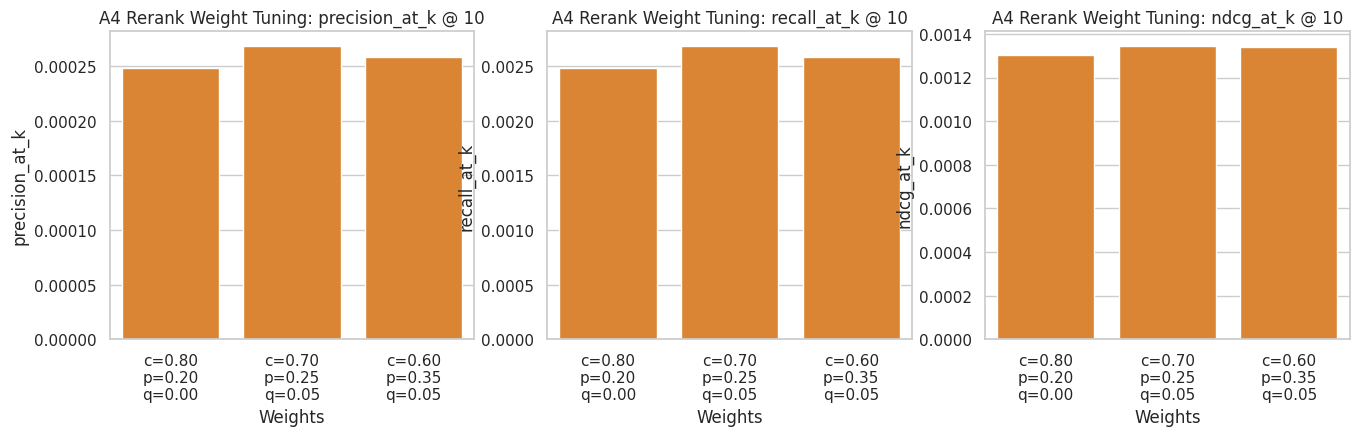

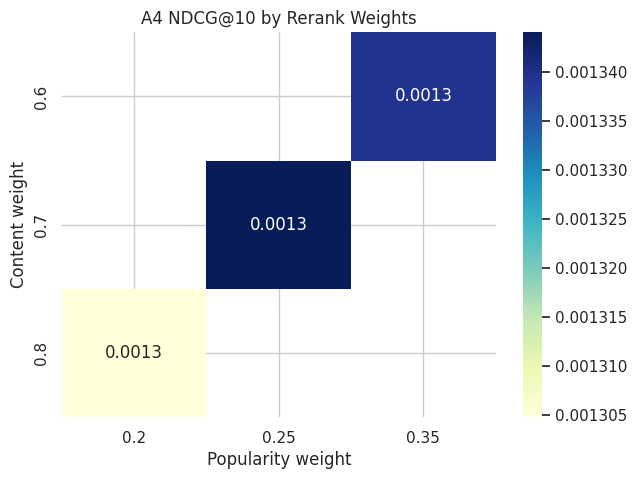

In [24]:
plot_df = rerank_tuning_df[rerank_tuning_df["k"] == CONFIG.primary_k].copy()
plot_df["weights"] = plot_df.apply(
    lambda r: f"c={r['content_weight']:.2f}\np={r['popularity_weight']:.2f}\nq={r['practical_weight']:.2f}", axis=1
)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric in zip(axes, ["precision_at_k", "recall_at_k", "ndcg_at_k"]):
    sns.barplot(data=plot_df, x="weights", y=metric, ax=ax, color="#F58518")
    ax.set_title(f"A4 Rerank Weight Tuning: {metric} @ {CONFIG.primary_k}")
    ax.set_xlabel("Weights")
    ax.set_ylabel(metric)
savefig("version_a_a4_rerank_weight_tuning.png")
plt.show()

heatmap_df = plot_df.pivot_table(
    index="content_weight", columns="popularity_weight", values="ndcg_at_k", aggfunc="mean"
)
plt.figure(figsize=(7, 5))
sns.heatmap(heatmap_df, annot=True, fmt=".4f", cmap="YlGnBu")
plt.title(f"A4 NDCG@{CONFIG.primary_k} by Rerank Weights")
plt.xlabel("Popularity weight")
plt.ylabel("Content weight")
savefig("version_a_a4_rerank_weight_heatmap.png")
plt.show()

# A5 Required: Latent Semantic Content Model

A5 is now a required Version A model. It applies `TruncatedSVD` to the TF-IDF matrix and evaluates a dense semantic user-profile recommender. This gives Version A a stronger semantic content comparison model beyond literal TF-IDF overlap. The fitted SVD model, components, and item embeddings are saved under `Experiments/model_artifacts/`.

In [25]:
class SVDContentRecommender:
    def __init__(
        self,
        artifacts: ContentArtifacts,
        train_seen_by_user: dict[int, set[int]],
        fallback_model: BayesianPopularityRecommender,
        n_components: int = 128,
    ):
        self.artifacts = artifacts
        self.train_seen_by_user = train_seen_by_user
        self.fallback_model = fallback_model
        self.n_components = n_components
        self.recipe_id_to_index = {int(rid): idx for idx, rid in enumerate(artifacts.recipes["id"].to_numpy(dtype=np.int64))}
        self.svd: TruncatedSVD | None = None
        self.item_embeddings: np.ndarray | None = None

    def fit(self) -> "SVDContentRecommender":
        start = now()
        self.svd = TruncatedSVD(n_components=self.n_components, random_state=RANDOM_STATE)
        embeddings = self.svd.fit_transform(self.artifacts.tfidf_matrix).astype(np.float32)
        norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
        self.item_embeddings = embeddings / np.maximum(norms, 1e-9)
        log_phase(
            f"fit A5 SVD n_components={self.n_components}",
            start,
            explained_variance=float(self.svd.explained_variance_ratio_.sum()),
        )
        return self

    def recommend(self, user_id: int, n: int = 10) -> pd.DataFrame:
        if self.item_embeddings is None:
            raise RuntimeError("Call fit() before recommend().")
        liked = get_liked_history(user_id)
        if liked.empty:
            return self.fallback_model.recommend(user_id=user_id, n=n)
        liked_indices = [self.recipe_id_to_index.get(int(rid)) for rid in liked["recipe_id"]]
        liked_indices = [idx for idx in liked_indices if idx is not None]
        if not liked_indices:
            return self.fallback_model.recommend(user_id=user_id, n=n)
        weights = liked["rating"].head(len(liked_indices)).to_numpy(dtype=np.float32)
        profile = np.average(self.item_embeddings[liked_indices], axis=0, weights=weights)
        profile = profile / max(np.linalg.norm(profile), 1e-9)
        candidate_embeddings = self.item_embeddings[self.artifacts.candidate_indices]
        scores = candidate_embeddings @ profile
        seen = self.train_seen_by_user.get(int(user_id), set())
        if seen:
            seen_mask = np.isin(self.artifacts.candidate_recipe_ids, list(seen))
            scores[seen_mask] = -np.inf
        local_top = top_indices_from_scores(scores, n)
        recipe_indices = self.artifacts.candidate_indices[local_top]
        recs = self.artifacts.recipes.iloc[recipe_indices][["id", "name", "minutes", "quick_recipe", "history_bucket"]].copy()
        recs = recs.rename(columns={"id": "recipe_id"})
        recs["score"] = scores[local_top]
        recs["reason"] = f"latent semantic content profile, n_components={self.n_components}"
        return recs.reset_index(drop=True)

svd_tuning_frames = []
svd_models: dict[str, SVDContentRecommender] = {}

if not CONFIG.run_svd_model:
    raise ValueError("A5 is required for Version A. Keep CONFIG.run_svd_model = True.")

for n_components in CONFIG.svd_components_grid:
    svd_model = SVDContentRecommender(
        best_artifacts,
        train_seen_by_user,
        best_popularity_model,
        n_components=n_components,
    ).fit()
    model_id = f"A5_{n_components}"
    svd_models[model_id] = svd_model

    if svd_model.svd is not None:
        save_pickle_artifact(svd_model.svd, f"{model_id}_truncated_svd.pkl")
        save_numpy_artifact(svd_model.svd.components_.astype(np.float32), f"{model_id}_svd_components.npy")
        save_numpy_artifact(
            svd_model.svd.explained_variance_ratio_.astype(np.float32),
            f"{model_id}_explained_variance_ratio.npy",
        )
    if svd_model.item_embeddings is not None:
        save_numpy_artifact(svd_model.item_embeddings.astype(np.float32), f"{model_id}_item_embeddings.npy")

    summary, per_user, recs = evaluate_recommender(
        svd_model,
        model_id=model_id,
        model_name=f"SVD semantic content {n_components}",
        users=eval_users,
        split_name="filtered_temporal_sample" if CONFIG.fast_dev_mode else "filtered_temporal",
        keep_recommendations=True,
    )
    summary["n_components"] = n_components
    svd_tuning_frames.append(summary)
    all_metrics.append(summary)
    all_per_user.append(per_user)
    all_recommendations.append(recs)

svd_tuning_df = pd.concat(svd_tuning_frames, ignore_index=True)
all_tuning_rows.append(svd_tuning_df.assign(tuning_family="svd_components"))

best_svd_row = svd_tuning_df[svd_tuning_df["k"] == CONFIG.primary_k].sort_values(
    ["ndcg_at_k", "recall_at_k", "precision_at_k"], ascending=False
).iloc[0]
BEST_SVD_MODEL_ID = str(best_svd_row["model_id"])
BEST_SVD_COMPONENTS = int(best_svd_row["n_components"])
save_json_artifact(
    {
        "model_family": "A5 SVD semantic content",
        "best_model_id": BEST_SVD_MODEL_ID,
        "best_n_components": BEST_SVD_COMPONENTS,
        "evaluated_components": list(CONFIG.svd_components_grid),
        "artifact_files": sorted(path.name for path in ARTIFACT_DIR.glob("A5_*")),
    },
    "a5_svd_metadata.json",
)

display(svd_tuning_df)

fit A5 SVD n_components=64: 8.97s


Evaluating A5_64:   0%|          | 0/10069 [00:00<?, ?it/s]

evaluate A5_64: 129.84s
fit A5 SVD n_components=128: 18.03s


Evaluating A5_128:   0%|          | 0/10069 [00:00<?, ?it/s]

evaluate A5_128: 157.62s


,model_id,model_name,split,k,evaluated_users,precision_at_k,recall_at_k,ndcg_at_k,hit_rate_at_k,catalog_coverage_at_k,recommend_seconds_total,recommend_seconds_per_user,errors,n_components
0,A5_64,SVD semantic content 64,filtered_temporal,5,10069,0.000179,0.000894,0.000517,0.000894,0.423750,129.497847,0.012861,0,64
1,A5_64,SVD semantic content 64,filtered_temporal,10,10069,0.000149,0.001490,0.000696,0.001490,0.583005,129.497847,0.012861,0,64
2,A5_128,SVD semantic content 128,filtered_temporal,5,10069,0.000238,0.001192,0.000671,0.001192,0.439383,157.285970,0.015621,0,128
3,A5_128,SVD semantic content 128,filtered_temporal,10,10069,0.000209,0.002086,0.000956,0.002086,0.595067,157.285970,0.015621,0,128


# Final Version A Comparison

This section combines metrics, runtime, tuning results, and recommendations from all completed Version A models.

In [26]:
metrics_df = pd.concat(all_metrics, ignore_index=True) if all_metrics else pd.DataFrame()
per_user_df = pd.concat(all_per_user, ignore_index=True) if all_per_user else pd.DataFrame()
recommendations_df = pd.concat(all_recommendations, ignore_index=True) if all_recommendations else pd.DataFrame()
tuning_df = pd.concat(all_tuning_rows, ignore_index=True) if all_tuning_rows else pd.DataFrame()
phase_df = pd.DataFrame(phase_log)

metrics_path = RESULTS_DIR / "version_a_metrics.csv"
per_user_path = RESULTS_DIR / "version_a_per_user_metrics.csv"
recommendations_path = RESULTS_DIR / "version_a_example_recommendations.csv"
tuning_path = RESULTS_DIR / "version_a_tuning_results.csv"
phase_path = RESULTS_DIR / "version_a_phase_runtime.csv"
config_path = RESULTS_DIR / "version_a_config.json"
model_artifact_manifest_path = ARTIFACT_DIR / "model_artifact_manifest.json"

metrics_df.to_csv(metrics_path, index=False)
per_user_df.to_csv(per_user_path, index=False)
recommendations_df.to_csv(recommendations_path, index=False)
tuning_df.to_csv(tuning_path, index=False)
phase_df.to_csv(phase_path, index=False)
config_path.write_text(json.dumps(asdict(CONFIG), indent=2, default=str))
model_artifact_manifest_path.write_text(
    json.dumps(
        {
            "artifact_dir": str(ARTIFACT_DIR),
            "files": sorted(path.name for path in ARTIFACT_DIR.iterdir() if path.is_file()),
        },
        indent=2,
        default=str,
    ),
    encoding="utf-8",
)

print("Saved:")
for path in [metrics_path, per_user_path, recommendations_path, tuning_path, phase_path, config_path, model_artifact_manifest_path]:
    print("-", path)

display(metrics_df.sort_values(["k", "ndcg_at_k"], ascending=[True, False]))

Saved:
- /content/drive/MyDrive/513/Final/Version_A/Results/version_a_metrics.csv
- /content/drive/MyDrive/513/Final/Version_A/Results/version_a_per_user_metrics.csv
- /content/drive/MyDrive/513/Final/Version_A/Results/version_a_example_recommendations.csv
- /content/drive/MyDrive/513/Final/Version_A/Results/version_a_tuning_results.csv
- /content/drive/MyDrive/513/Final/Version_A/Results/version_a_phase_runtime.csv
- /content/drive/MyDrive/513/Final/Version_A/Results/version_a_config.json
- /content/drive/MyDrive/513/Final/Version_A/Experiments/model_artifacts/model_artifact_manifest.json


,model_id,model_name,split,k,evaluated_users,precision_at_k,recall_at_k,ndcg_at_k,hit_rate_at_k,catalog_coverage_at_k,recommend_seconds_total,recommend_seconds_per_user,errors,n_components
0,A0,Bayesian popularity baseline,filtered_temporal,5,10069,0.001251,0.006257,0.003434,0.006257,0.000311,35.142447,0.003490,0,NaN
6,A4,Content plus popularity reranker,filtered_temporal,5,10069,0.000298,0.001490,0.000952,0.001490,0.319987,617.533437,0.061330,0,NaN
4,A3,User-profile TF-IDF content,filtered_temporal,5,10069,0.000298,0.001490,0.000948,0.001490,0.322860,582.667159,0.057867,0,NaN
2,A2,TF-IDF item-to-item content,filtered_temporal,5,10069,0.000258,0.001291,0.000848,0.001291,0.306191,2876.173422,0.285646,0,NaN
10,A5_128,SVD semantic content 128,filtered_temporal,5,10069,0.000238,0.001192,0.000671,0.001192,0.439383,157.285970,0.015621,0,128.0
8,A5_64,SVD semantic content 64,filtered_temporal,5,10069,0.000179,0.000894,0.000517,0.000894,0.423750,129.497847,0.012861,0,64.0
1,A0,Bayesian popularity baseline,filtered_temporal,10,10069,0.001003,0.010031,0.004618,0.010031,0.000621,35.142447,0.003490,0,NaN
7,A4,Content plus popularity reranker,filtered_temporal,10,10069,0.000268,0.002681,0.001344,0.002681,0.452997,617.533437,0.061330,0,NaN
5,A3,User-profile TF-IDF content,filtered_temporal,10,10069,0.000268,0.002681,0.001321,0.002681,0.457397,582.667159,0.057867,0,NaN
3,A2,TF-IDF item-to-item content,filtered_temporal,10,10069,0.000218,0.002185,0.001134,0.002185,0.448520,2876.173422,0.285646,0,NaN


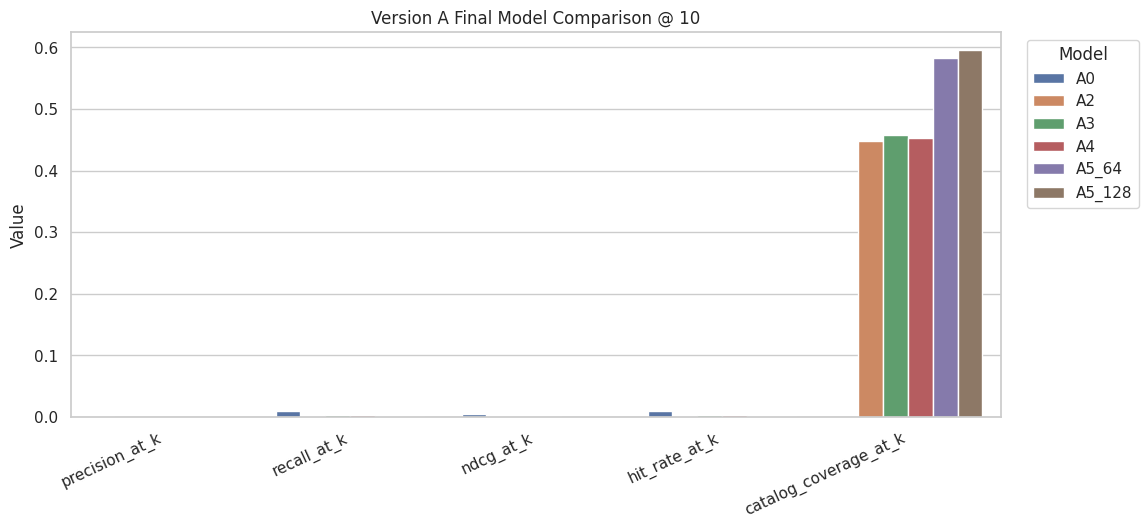

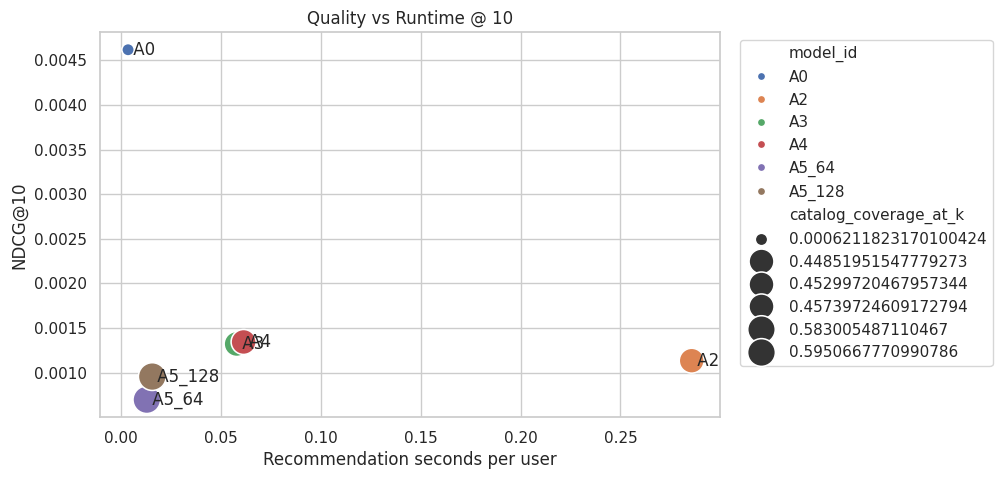

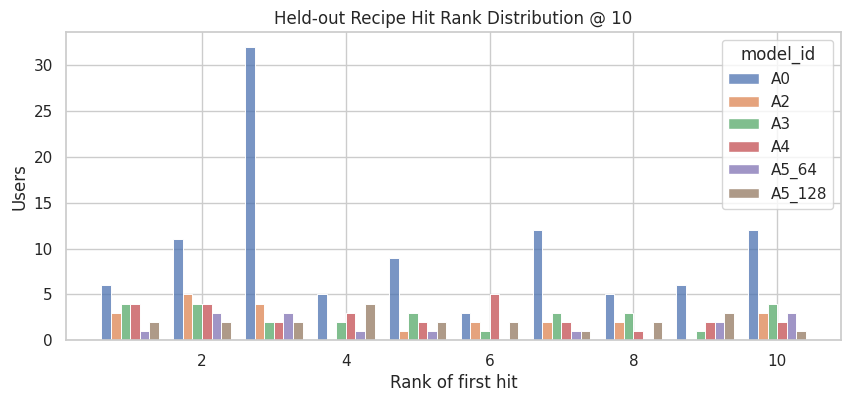

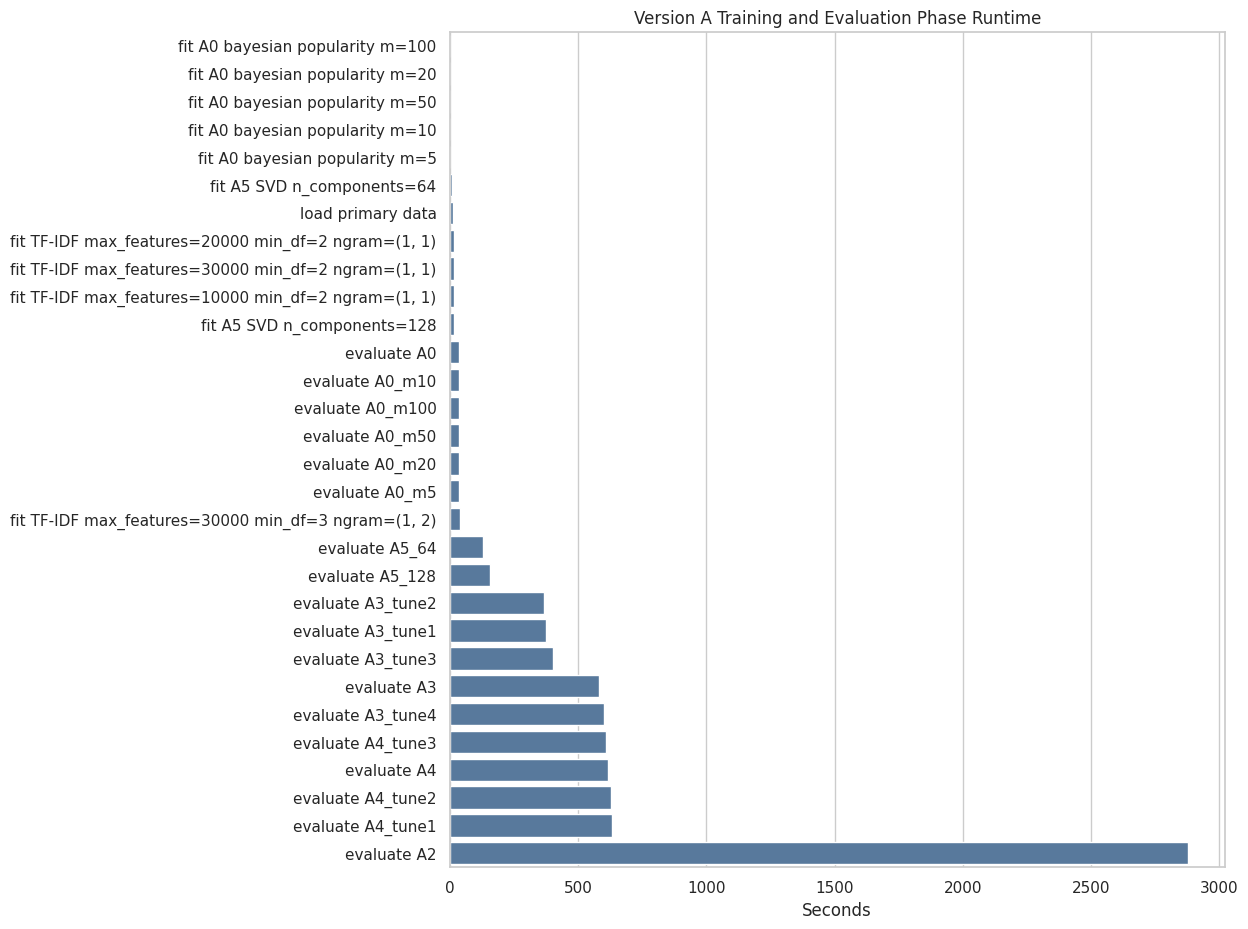

In [27]:
plot_metric_bars(metrics_df, k=CONFIG.primary_k, title="Version A Final Model Comparison")
plot_runtime_vs_quality(metrics_df, k=CONFIG.primary_k)
plot_hit_rank_distribution(per_user_df, k=CONFIG.primary_k)
phase_runtime_df = plot_phase_runtime()

### Example Successful Recommendations

,model_id,model_name,split,user_id,rank,recipe_id,score,name,minutes,is_test_hit,reason
5740,A0,Bayesian popularity baseline,filtered_temporal,43360,1,78579,4.880357,pan release professional pan coating better than pam spray,5,1,"high train-only Bayesian popularity score, m=100"
32410,A0,Bayesian popularity baseline,filtered_temporal,217724,1,78579,4.880357,pan release professional pan coating better than pam spray,5,1,"high train-only Bayesian popularity score, m=100"
58790,A0,Bayesian popularity baseline,filtered_temporal,464130,1,78579,4.880357,pan release professional pan coating better than pam spray,5,1,"high train-only Bayesian popularity score, m=100"
63490,A0,Bayesian popularity baseline,filtered_temporal,523073,1,78579,4.880357,pan release professional pan coating better than pam spray,5,1,"high train-only Bayesian popularity score, m=100"
73160,A0,Bayesian popularity baseline,filtered_temporal,683416,1,78579,4.880357,pan release professional pan coating better than pam spray,5,1,"high train-only Bayesian popularity score, m=100"
79310,A0,Bayesian popularity baseline,filtered_temporal,821030,1,78579,4.880357,pan release professional pan coating better than pam spray,5,1,"high train-only Bayesian popularity score, m=100"
30881,A0,Bayesian popularity baseline,filtered_temporal,206779,2,31128,4.874437,yummy crunchy apple pie,70,1,"high train-only Bayesian popularity score, m=100"
38301,A0,Bayesian popularity baseline,filtered_temporal,257146,2,31128,4.874437,yummy crunchy apple pie,70,1,"high train-only Bayesian popularity score, m=100"
44221,A0,Bayesian popularity baseline,filtered_temporal,315055,2,69173,4.872590,kittencal s italian melt in your mouth meatballs,50,1,"high train-only Bayesian popularity score, m=100"
44531,A0,Bayesian popularity baseline,filtered_temporal,317193,2,31128,4.874437,yummy crunchy apple pie,70,1,"high train-only Bayesian popularity score, m=100"


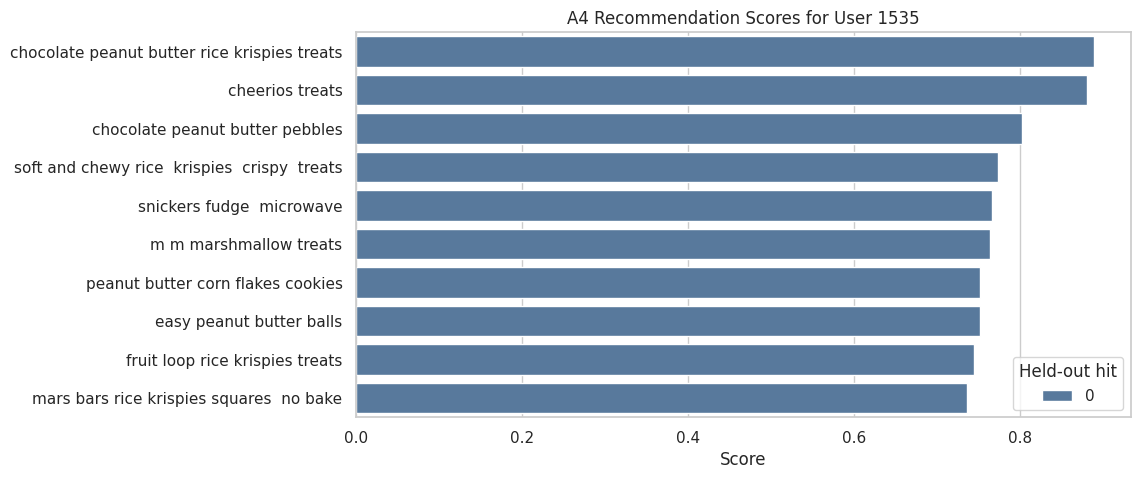

In [28]:
if not recommendations_df.empty:
    hit_examples = recommendations_df[recommendations_df["is_test_hit"] == 1].copy()
    if not hit_examples.empty:
        display_section("Example Successful Recommendations")
        display(hit_examples.sort_values(["model_id", "rank"]).head(20))
    else:
        display_section("Sample Recommendations")
        display(recommendations_df.sort_values(["model_id", "user_id", "rank"]).head(20))

    top_model = "A4" if "A4" in set(recommendations_df["model_id"]) else recommendations_df["model_id"].iloc[0]
    sample_user = int(recommendations_df[recommendations_df["model_id"] == top_model]["user_id"].iloc[0])
    sample_recs = recommendations_df[(recommendations_df["model_id"] == top_model) & (recommendations_df["user_id"] == sample_user)].copy()

    plt.figure(figsize=(10, 5))
    sns.barplot(data=sample_recs, y="name", x="score", hue="is_test_hit", dodge=False, palette={0: "#4C78A8", 1: "#E45756"})
    plt.title(f"{top_model} Recommendation Scores for User {sample_user}")
    plt.xlabel("Score")
    plt.ylabel("")
    plt.legend(title="Held-out hit")
    savefig("version_a_sample_recommendation_scores.png")
    plt.show()
else:
    print("No recommendation rows available yet.")

## Explainability Visualizations

These plots are for the presentation/report. They show why a content model recommended an item by comparing the user's liked-recipe profile with the recommended recipe terms.

,term,overlap_score
51,5_ingredients_or_less desserts,0.017002
41,desserts lunch,0.014958
48,chocolate,0.013243
50,bar_cookies,0.012549
46,cookies_and_brownies,0.010912
3,treats,0.010829
21,occasion 5_ingredients_or_less,0.010645
39,dietary gifts,0.010292
34,finger_food,0.009634
0,vegetarian cookies_and_brownies,0.009280


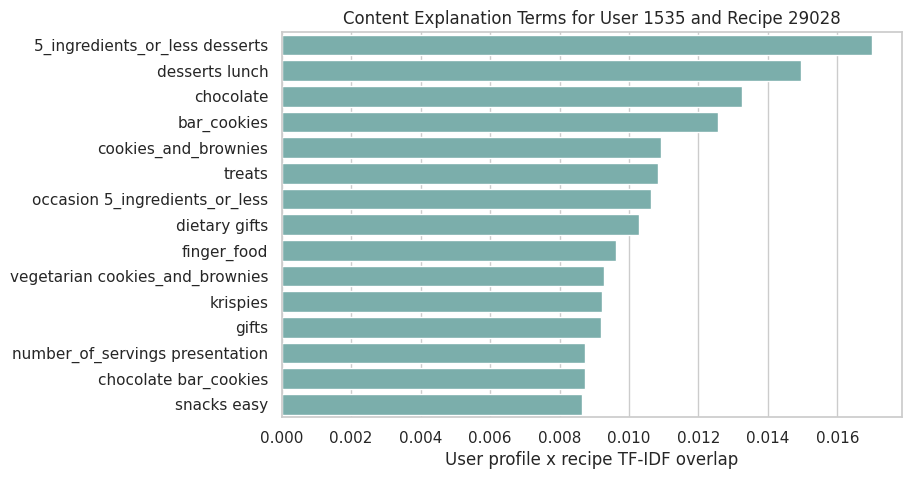

In [29]:
def explain_profile_recommendation(user_id: int, recipe_id: int, artifacts: ContentArtifacts, top_terms: int = 15) -> pd.DataFrame:
    profile = profile_content_model.build_user_profile(user_id)
    recipe_idx = recipe_id_to_index.get(int(recipe_id))
    if profile is None or recipe_idx is None:
        return pd.DataFrame()

    feature_names = np.asarray(artifacts.vectorizer.get_feature_names_out())
    recipe_vec = artifacts.tfidf_matrix[recipe_idx]
    overlap = profile.multiply(recipe_vec)
    if overlap.nnz == 0:
        return pd.DataFrame()

    coo = overlap.tocoo()
    rows = pd.DataFrame({
        "term": feature_names[coo.col],
        "overlap_score": coo.data,
    }).sort_values("overlap_score", ascending=False).head(top_terms)
    return rows

if not recommendations_df.empty:
    candidate = recommendations_df[recommendations_df["model_id"].isin(["A4", "A3"])].head(1)
    if not candidate.empty:
        user_id = int(candidate.iloc[0]["user_id"])
        recipe_id = int(candidate.iloc[0]["recipe_id"])
        explanation = explain_profile_recommendation(user_id, recipe_id, best_artifacts, top_terms=15)
        display(explanation)
        if not explanation.empty:
            plt.figure(figsize=(8, 5))
            sns.barplot(data=explanation, y="term", x="overlap_score", color="#72B7B2")
            plt.title(f"Content Explanation Terms for User {user_id} and Recipe {recipe_id}")
            plt.xlabel("User profile x recipe TF-IDF overlap")
            plt.ylabel("")
            savefig("version_a_content_explanation_terms.png")
            plt.show()
else:
    print("Run model evaluations first to generate explanations.")

# A1 Constraint Demo

This is a demo-friendly model rather than the main offline metric model. It shows how Version A supports practical recipe requests such as quick recipes or ingredient exclusions.

,scenario,recipe_id,name,minutes,quick_recipe,score
0,no constraint,78579,pan release professional pan coating better than pam spray,5,True,4.880357
1,no constraint,31128,yummy crunchy apple pie,70,False,4.874437
2,no constraint,69173,kittencal s italian melt in your mouth meatballs,50,False,4.872590
3,no constraint,46262,uncle bill s method for cooking turkey,330,False,4.869658
4,no constraint,221743,kittencal s best blasted rapid roast whole chicken,80,False,4.867383
5,no constraint,30358,perfect pasta with no watching and no sweating,18,True,4.857233
6,no constraint,107786,beth s melt in your mouth barbecue ribs oven,195,False,4.857228
7,no constraint,177558,oven roasted corn on the cob,30,True,4.852478
8,no constraint,89207,kittencal s chocolate frosting icing,5,True,4.851985
9,no constraint,111777,chicken pot pie with 2 crusts,70,False,4.851786


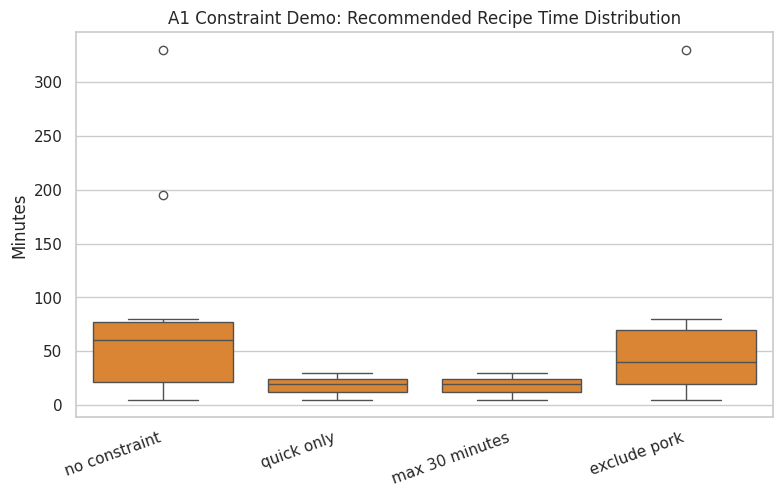

In [30]:
def run_constraint_demo(user_id: int | None = None) -> pd.DataFrame:
    if user_id is None:
        user_id = int(eval_users[0])
    scenarios = [
        {"scenario": "no constraint", "kwargs": {}},
        {"scenario": "quick only", "kwargs": {"require_quick": True}},
        {"scenario": "max 30 minutes", "kwargs": {"max_minutes": 30}},
        {"scenario": "exclude pork", "kwargs": {"exclude_terms": ("pork",)}},
    ]
    frames = []
    for scenario in scenarios:
        recs = best_popularity_model.recommend(user_id=user_id, n=10, **scenario["kwargs"])
        recs["scenario"] = scenario["scenario"]
        frames.append(recs)
    out = pd.concat(frames, ignore_index=True)
    return out

constraint_demo = run_constraint_demo()
display(constraint_demo[["scenario", "recipe_id", "name", "minutes", "quick_recipe", "score"]].head(40))

plt.figure(figsize=(9, 5))
sns.boxplot(data=constraint_demo, x="scenario", y="minutes", color="#F58518")
plt.title("A1 Constraint Demo: Recommended Recipe Time Distribution")
plt.xlabel("")
plt.ylabel("Minutes")
plt.xticks(rotation=20, ha="right")
savefig("version_a_constraint_demo_minutes.png")
plt.show()

# Optional Full Filtered Evaluation

After the sampled run is correct, run this cell for the full filtered temporal test users. This is the number to use in the final comparison table if runtime is acceptable.

Evaluating A0_full:   0%|          | 0/10069 [00:00<?, ?it/s]

evaluate A0_full: 26.62s


Evaluating A3_full:   0%|          | 0/10069 [00:00<?, ?it/s]

evaluate A3_full: 720.66s


Evaluating A4_full:   0%|          | 0/10069 [00:00<?, ?it/s]

evaluate A4_full: 751.22s


Evaluating A5_full:   0%|          | 0/10069 [00:00<?, ?it/s]

evaluate A5_full: 156.44s


,model_id,model_name,split,k,evaluated_users,precision_at_k,recall_at_k,ndcg_at_k,hit_rate_at_k,catalog_coverage_at_k,recommend_seconds_total,recommend_seconds_per_user,errors
0,A0_full,Bayesian popularity baseline full,filtered_temporal_full,5,10069,0.001251,0.006257,0.003434,0.006257,0.000311,26.579341,0.002640,0
1,A0_full,Bayesian popularity baseline full,filtered_temporal_full,10,10069,0.001003,0.010031,0.004618,0.010031,0.000621,26.579341,0.002640,0
2,A3_full,User-profile TF-IDF content full,filtered_temporal_full,5,10069,0.000298,0.001490,0.000948,0.001490,0.322860,720.612801,0.071567,0
3,A3_full,User-profile TF-IDF content full,filtered_temporal_full,10,10069,0.000268,0.002681,0.001321,0.002681,0.457397,720.612801,0.071567,0
4,A4_full,Content plus popularity reranker full,filtered_temporal_full,5,10069,0.000298,0.001490,0.000952,0.001490,0.319987,751.176271,0.074603,0
5,A4_full,Content plus popularity reranker full,filtered_temporal_full,10,10069,0.000268,0.002681,0.001344,0.002681,0.452997,751.176271,0.074603,0
6,A5_full,SVD semantic content full,filtered_temporal_full,5,10069,0.000238,0.001192,0.000671,0.001192,0.439383,156.366676,0.015530,0
7,A5_full,SVD semantic content full,filtered_temporal_full,10,10069,0.000209,0.002086,0.000956,0.002086,0.595067,156.366676,0.015530,0


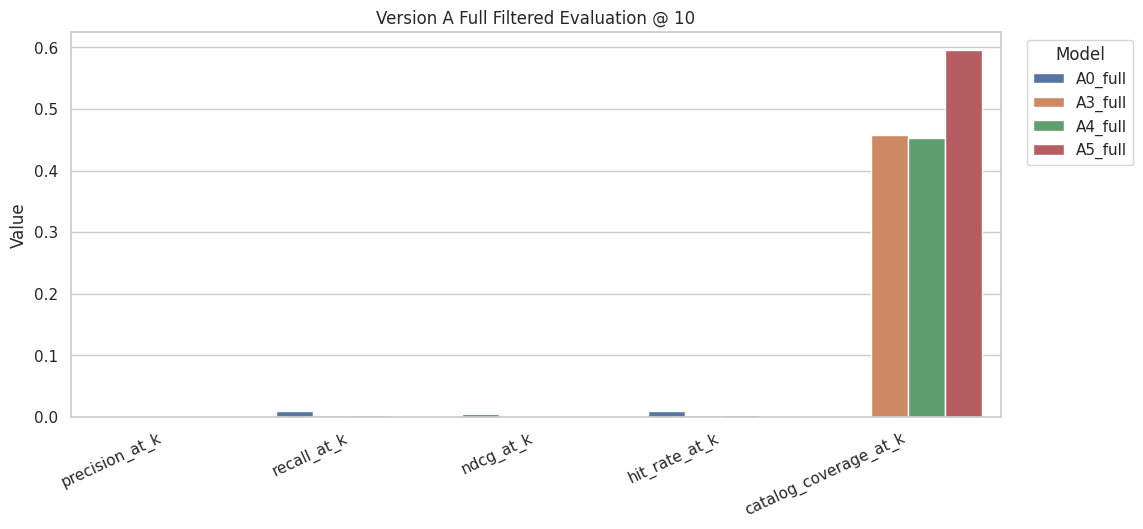

In [31]:
if CONFIG.run_full_filtered_eval:
    full_eval_users = all_eval_users
    full_models = [
        ("A0_full", "Bayesian popularity baseline full", best_popularity_model),
        ("A3_full", "User-profile TF-IDF content full", profile_content_model),
        ("A4_full", "Content plus popularity reranker full", best_rerank_model),
    ]
    if "BEST_SVD_MODEL_ID" in globals() and BEST_SVD_MODEL_ID in svd_models:
        full_models.append(("A5_full", "SVD semantic content full", svd_models[BEST_SVD_MODEL_ID]))
    full_metric_frames = []
    for model_id, model_name, model in full_models:
        summary, per_user, recs = evaluate_recommender(
            model,
            model_id=model_id,
            model_name=model_name,
            users=full_eval_users,
            split_name="filtered_temporal_full",
            keep_recommendations=False,
        )
        full_metric_frames.append(summary)
    full_metrics_df = pd.concat(full_metric_frames, ignore_index=True)
    full_metrics_df.to_csv(RESULTS_DIR / "version_a_full_filtered_metrics.csv", index=False)
    display(full_metrics_df)
    plot_metric_bars(full_metrics_df, k=CONFIG.primary_k, title="Version A Full Filtered Evaluation")
else:
    print("Full filtered evaluation skipped. Set CONFIG.run_full_filtered_eval = True to run it.")

# Optional Secondary Clean-Split Coverage Analysis

This is for Version A's sparse-history story. It evaluates broader metadata coverage using `interactions_train.csv` and `interactions_test.csv`. It may be slower and memory heavier.

In [32]:
if CONFIG.run_secondary_clean_eval:
    start = now()
    clean_train = pd.read_csv(DATA_DIR / "interactions_train.csv", parse_dates=["date"])
    clean_test = pd.read_csv(DATA_DIR / "interactions_test.csv", parse_dates=["date"])
    log_phase("load secondary clean split", start, train_rows=len(clean_train), test_rows=len(clean_test))

    clean_summary = pd.DataFrame([
        {"metric": "clean_train_rows", "value": len(clean_train)},
        {"metric": "clean_test_rows", "value": len(clean_test)},
        {"metric": "clean_train_users", "value": clean_train["user_id"].nunique()},
        {"metric": "clean_test_users", "value": clean_test["user_id"].nunique()},
        {"metric": "filtered_test_users", "value": test["user_id"].nunique()},
    ])
    display(clean_summary)

    plt.figure(figsize=(8, 4))
    sns.barplot(data=clean_summary, x="metric", y="value", color="#B279A2")
    plt.title("Clean Split vs Filtered Split Coverage")
    plt.xticks(rotation=30, ha="right")
    plt.xlabel("")
    plt.ylabel("Count")
    savefig("version_a_clean_vs_filtered_coverage.png")
    plt.show()
else:
    print("Secondary clean-split coverage analysis skipped. Set CONFIG.run_secondary_clean_eval = True to run it.")

Secondary clean-split coverage analysis skipped. Set CONFIG.run_secondary_clean_eval = True to run it.


# Report Checklist

After running the notebook, use these generated artifacts in the final report or presentation:

- `version_a_metrics.csv`
- `version_a_tuning_results.csv`
- `version_a_phase_runtime.csv`
- `version_a_example_recommendations.csv`
- `Experiments/model_artifacts/*`
- `Figures/version_a_a0_popularity_tuning.png`
- `Figures/version_a_a3_tfidf_tuning.png`
- `Figures/version_a_a4_rerank_weight_tuning.png`
- `Figures/version_a_model_metrics_at_10.png`
- `Figures/version_a_quality_vs_runtime_at_10.png`
- `Figures/version_a_hit_rank_distribution_at_10.png`
- `Figures/version_a_content_explanation_terms.png`

Recommended final story:

1. A0 is the fair non-personalized baseline.
2. A2 and A3 show metadata can personalize without collaborative filtering.
3. A4 is Version A's best candidate because it balances personalization, quality, and practical constraints.
4. Version A is especially valuable for sparse users/items and explanation-friendly recipe recommendations.